In [3]:
# Ячейка 1: Импорты и настройки
import os
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import re
import yaml
import json

# Параметры отображения
pd.set_option('display.max_columns', None)

In [4]:
# Ячейка 2 (исправленная): Функции загрузки датасетов (добавлен reset_index)

def load_nsl_kdd(train_path, test_path):
    columns = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
        'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
        'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
        'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
        'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
        'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
    ]
    df_train = pd.read_csv(train_path, header=None, names=columns)
    df_test = pd.read_csv(test_path, header=None, names=columns)
    df_train.drop(columns=['difficulty'], inplace=True)
    df_test.drop(columns=['difficulty'], inplace=True)
    df = pd.concat([df_train, df_test], ignore_index=True)
    return df.reset_index(drop=True)  # сброс индекса

def load_cicids2017(directory):
    all_files = [f for f in os.listdir(directory) if f.endswith('.parquet')]
    if not all_files:
        raise FileNotFoundError(f"Не найдено .parquet файлов в {directory}")
    dfs = []
    for f in all_files:
        fp = os.path.join(directory, f)
        df = pd.read_parquet(fp)
        if 'Label' in df.columns:
            df.rename(columns={'Label': 'label'}, inplace=True)
        if 'label' not in df.columns:
            print(f"Пропускаем {f} — нет столбца с меткой")
            continue
        dfs.append(df)
    if not dfs:
        raise ValueError("Ни в одном файле нет столбца 'label' или 'Label'")
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df.reset_index(drop=True)

def load_unsw_nb15(directory):
    train_path = os.path.join(directory, 'UNSW_NB15_training-set.parquet')
    test_path = os.path.join(directory, 'UNSW_NB15_testing-set.parquet')
    if not (os.path.exists(train_path) and os.path.exists(test_path)):
        raise FileNotFoundError("Отсутствуют файлы UNSW_NB15_training-set.parquet / testing-set.parquet")
    
    df_train = pd.read_parquet(train_path)
    df_test = pd.read_parquet(test_path)
    
    # Обрабатываем каждый DataFrame
    for df_ in (df_train, df_test):
        if 'attack_cat' in df_.columns:
            # Удаляем числовой label, если он есть
            df_.drop(columns=['label'], inplace=True, errors='ignore')
            # Переименовываем attack_cat в label
            df_.rename(columns={'attack_cat': 'label'}, inplace=True)
        elif 'label' not in df_.columns:
            raise KeyError("Нет ни 'label', ни 'attack_cat' в UNSW-NB15")
    
    df = pd.concat([df_train, df_test], ignore_index=True)
    
    # Принудительно делаем метки строками (на случай, если остались числа)
    df['label'] = df['label'].astype(str)
    return df.reset_index(drop=True)

In [5]:
# Ячейка 3: Вспомогательные функции метрик (без изменений, оставлены для ясности)

def compute_ir_gini(y):
    """Imbalance Ratio и индекс Джини."""
    vc = y.value_counts()
    ir = vc.max() / vc.min()
    p = vc / len(y)
    gini = 1 - np.sum(p**2)
    return ir, gini

def compute_duplicate_rate(df):
    return df.duplicated().sum() / len(df)

def compute_missing_rate(df):
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    return missing_cells / total_cells

def compute_invalid_rate(df):
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) == 0:
        return 0.0
    inf_mask = np.isinf(df[num_cols])
    nan_mask = df[num_cols].isnull()
    invalid_count = inf_mask.sum().sum() + nan_mask.sum().sum()
    total_numeric = len(df) * len(num_cols)
    return invalid_count / total_numeric

def compute_mmi(X, y, sample_size=10000):
    """
    Средняя взаимная информация. Для больших датасетов используется подвыборка sample_size.
    Возвращает (mean_mi, max_mi).
    """
    if len(X) > sample_size:
        # стратифицированная подвыборка для скорости
        rng = np.random.default_rng(42)
        # стараемся сохранить распределение классов
        y_unique = y.unique()
        indices = []
        for cls in y_unique:
            cls_idx = y[y == cls].index
            n_sample = min(len(cls_idx), max(1, int(sample_size / len(y_unique))))
            indices.extend(rng.choice(cls_idx, size=n_sample, replace=False))
        rng.shuffle(indices)
        X_sub = X.loc[indices]
        y_sub = y.loc[indices]
    else:
        X_sub = X
        y_sub = y
    
    num_cols = X_sub.select_dtypes(include=[np.number]).columns
    cat_cols = X_sub.select_dtypes(exclude=[np.number]).columns
    
    mi_scores = []
    # числовые признаки
    if len(num_cols) > 0:
        mi_num = mutual_info_classif(X_sub[num_cols].fillna(0), y_sub, discrete_features=False, random_state=42)
        mi_scores.extend(mi_num)
    # категориальные
    for col in cat_cols:
        le = LabelEncoder()
        x_enc = le.fit_transform(X_sub[col].astype(str).fillna('missing'))
        mi = mutual_info_classif(x_enc.reshape(-1,1), y_sub, discrete_features=True, random_state=42)[0]
        mi_scores.append(mi)
    
    if not mi_scores:
        return 0.0, 0.0
    max_mi = max(mi_scores)
    mean_mi = np.mean(mi_scores)
    return mean_mi, max_mi

def compute_consistency(df):
    """Доля противоречивых дубликатов (разные метки)."""
    feature_cols = [c for c in df.columns if c != 'label']
    dup_mask = df.duplicated(subset=feature_cols, keep=False)
    if dup_mask.sum() == 0:
        return 0.0
    dup_groups = df[dup_mask].groupby(feature_cols, observed=False)['label']
    inconsistent = 0
    for _, group in dup_groups:
        if group.nunique() > 1:
            inconsistent += len(group)
    return inconsistent / dup_mask.sum()

def scan_for_ip(df):
    """Обнаружение столбцов с IP-адресами."""
    ipv4 = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
    ipv6 = re.compile(r'\b(?:[0-9a-fA-F]{0,4}:){2,}[0-9a-fA-F]{0,4}\b')
    for col in df.select_dtypes(include=['object', 'string']).columns:
        col_vals = df[col].dropna().astype(str)
        if any(ipv4.search(val) or ipv6.search(val) for val in col_vals):
            return True
    return False

In [6]:
# Ячейка 4 (исправленная версия)

def evaluate_dataset(df, dataset_name, manual_scores):
    y = df['label'].copy()
    # Приводим метки к строковому типу
    if not pd.api.types.is_string_dtype(y):
        if pd.api.types.is_categorical_dtype(y):
            y = y.astype(str)
        else:
            y = y.astype(str)
    X = df.drop(columns=['label'])
    
    res = {'dataset': dataset_name}
    
    # Блок T – ручные оценки
    t_keys = ['T_env_realism', 'T_pcap_available', 'T_labeling_quality',
              'T_network_completeness', 'T_documentation', 'T_train_test_split']
    for k in t_keys:
        res[k] = manual_scores.get(k, None)
    
    # Блок G
    counts = y.value_counts()
    min_thresh = 50
    n_valid = (counts >= min_thresh).sum()
    n_total = len(counts)
    
    normal_labels = {'normal', 'benign'}
    n_attack_types = sum(1 for lbl in counts.index if lbl.lower() not in normal_labels)
    if n_attack_types == 0:
        n_attack_types = n_total
    n_expected = 14   # можно настраивать
    
    # Полнота: ограничиваем результат до 1.0
    C_comp = (n_valid / n_total) * (n_attack_types / n_expected) if n_total else 0
    C_comp = min(C_comp, 1.0)   # <-- исправление
    res['G_completeness'] = C_comp
    
    res['G_correctness'] = manual_scores.get('G_correctness', None)
    
    # Согласованность
    consistency_score = 1 - compute_consistency(df.assign(label=y))
    res['G_consistency'] = consistency_score
    
    # Актуальность: экспоненциальное затухание с полуустареванием T_decay = 5 лет
    year_created = manual_scores['year_created']
    year_eval = 2026
    T_decay = 5  # период полуустаревания (через 5 лет актуальность = 0.5)
    # C_curr = 2^(-(year_eval - year_created) / T_decay)
    age = max(0, year_eval - year_created)
    C_curr = 2 ** (-age / T_decay)   # <-- исправление
    res['G_currentness'] = C_curr
    
    # Блок A (пока ручная)
    res['A_acs'] = manual_scores.get('A_acs', None)
    
    # Блок S
    ir, gini = compute_ir_gini(y)
    res['S_imbalance_ratio'] = ir
    res['S_gini_index'] = gini
    res['S_duplicate_rate'] = compute_duplicate_rate(df)
    res['S_missing_rate'] = compute_missing_rate(df)
    res['S_invalid_rate'] = compute_invalid_rate(df)
    mean_mi, max_mi = compute_mmi(X, y)
    res['S_mean_mi'] = mean_mi
    res['S_max_mi'] = max_mi
    
    # Блок N
    #res['N_has_direct_ip'] = scan_for_ip(df)

    if dataset_name == 'CIC-IDS2017':
        res['N_has_direct_ip'] =0.5
    elif  scan_for_ip(df) == True:
        res['N_has_direct_ip'] =0
    else:
        res['N_has_direct_ip'] =1
    
    n_keys = ['N_anonymization_documented',
              'N_env_legal_status','N_commercial_restrictions']
    for key in n_keys:
        res[key] = manual_scores.get(key, None)
    
    return res

In [18]:
# Ячейка 5: Загрузка всех трёх датасетов и вычисление метрик

# Базовый путь
base = "/Users/anna/VKR_2026"

# NSL-KDD
nsl_train = os.path.join(base, "NSL-KDD", "KDDTrain+.txt")
nsl_test  = os.path.join(base, "NSL-KDD", "KDDTest+.txt")
df_nsl = load_nsl_kdd(nsl_train, nsl_test) if os.path.exists(nsl_train) and os.path.exists(nsl_test) else None

# UNSW-NB15
unsw_dir = os.path.join(base, "UNSW-NB15")
df_unsw = load_unsw_nb15(unsw_dir) if os.path.isdir(unsw_dir) else None

# CIC-IDS2017
cic_dir = os.path.join(base, "CIC-IDS2017")
df_cic = load_cicids2017(cic_dir) if os.path.isdir(cic_dir) else None

# Проверка, что label является одномерным
for name, df in [("NSL-KDD", df_nsl), ("UNSW-NB15", df_unsw), ("CIC-IDS2017", df_cic)]:
    if df is not None:
        assert isinstance(df['label'], pd.Series), f"В {name} 'label' не Series, а {type(df['label'])}"
        print(f"{name}: label колонка в порядке, shape={df.shape}")

print("Загрузка завершена:")
for name, df in [("NSL-KDD", df_nsl), ("UNSW-NB15", df_unsw), ("CIC-IDS2017", df_cic)]:
    if df is not None:
        print(f"{name}: {df.shape}")
    else:
        print(f"{name}: не загружен")

NSL-KDD: label колонка в порядке, shape=(148517, 42)
UNSW-NB15: label колонка в порядке, shape=(257673, 35)
CIC-IDS2017: label колонка в порядке, shape=(2313810, 78)
Загрузка завершена:
NSL-KDD: (148517, 42)
UNSW-NB15: (257673, 35)
CIC-IDS2017: (2313810, 78)


In [19]:
# Ячейка 6: Ручные оценки (согласованные с описанием в отчёте)

manual_nsl = {
    'T_env_realism': 0.5,
    'T_pcap_available': 0,
    'T_labeling_quality': 0.5,
    'T_network_completeness': 0.6,
    'T_documentation': 0.5,
    'T_train_test_split': 1,
    'G_correctness': 0.5,
    'year_created': 2009,
    'A_acs': 0.3,
    # 'N_anonymization_degree': 1,
    'N_anonymization_documented': 0,
    'N_env_legal_status': 1,
    'N_commercial_restrictions': 1
}

manual_unsw = {
    'T_env_realism': 0.5,
    'T_pcap_available': 1,
    'T_labeling_quality': 0.5,
    'T_network_completeness': 0.7,
    'T_documentation': 0.5,
    'T_train_test_split': 1,
    'G_correctness': 0.5,
    'year_created': 2015,
    'A_acs': 0.5,
    # 'N_anonymization_degree': 1,
    'N_anonymization_documented': 0,
    'N_env_legal_status': 1,
    'N_commercial_restrictions': 1
}

manual_cic = {
    'T_env_realism': 1,
    'T_pcap_available': 1,
    'T_labeling_quality': 0.5,
    'T_network_completeness': 0.8,
    'T_documentation': 0.5,
    'T_train_test_split': 0,
    'G_correctness': 0.5,
    'year_created': 2017,
    'A_acs': 0.65,
    # 'N_anonymization_degree': 0.5,
    # 'N_has_direct_ip': 0.5,
    'N_anonymization_documented': 0,
    'N_env_legal_status': 0.5,
    'N_commercial_restrictions': 1
}


In [20]:
# Ячейка 7: Расчёт метрик и вывод результатов

results = {}
if df_nsl is not None:
    results['NSL-KDD'] = evaluate_dataset(df_nsl, 'NSL-KDD', manual_nsl)
if df_unsw is not None:
    results['UNSW-NB15'] = evaluate_dataset(df_unsw, 'UNSW-NB15', manual_unsw)
if df_cic is not None:
    results['CIC-IDS2017'] = evaluate_dataset(df_cic, 'CIC-IDS2017', manual_cic)

for name, res in results.items():
    print(f"\n{'='*40}\n{name}\n{'='*40}")
    for k, v in res.items():
        if isinstance(v, float):
            print(f"{k:30s}: {v:.4f}")
        else:
            print(f"{k:30s}: {v}")


NSL-KDD
dataset                       : NSL-KDD
T_env_realism                 : 0.5000
T_pcap_available              : 0
T_labeling_quality            : 0.5000
T_network_completeness        : 0.6000
T_documentation               : 0.5000
T_train_test_split            : 1
G_completeness                : 1.0000
G_correctness                 : 0.5000
G_consistency                 : 0.8284
G_currentness                 : 0.0947
A_acs                         : 0.3000
S_imbalance_ratio             : 38527.0000
S_gini_index                  : 0.6325
S_duplicate_rate              : 0.0041
S_missing_rate                : 0.0000
S_invalid_rate                : 0.0000
S_mean_mi                     : 0.4990
S_max_mi                      : 2.1751
N_has_direct_ip               : 1
N_anonymization_documented    : 0
N_env_legal_status            : 1
N_commercial_restrictions     : 1

UNSW-NB15
dataset                       : UNSW-NB15
T_env_realism                 : 0.5000
T_pcap_available           

In [21]:
# Ячейка 8: Нормализация и агрегация метрик, расчет Q

def normalize_metrics(raw: dict) -> dict:
    """
    Принимает словарь исходных метрик (из evaluate_dataset), вычисляет
    нормализованные значения для каждого блока и агрегирует их.
    Возвращает словарь с блочными оценками T, G, S, A, N и нормированными метриками.
    """
    norm = {}
    
    # ---------- Блок T ----------
    t_keys = ['T_env_realism', 'T_pcap_available', 'T_labeling_quality',
              'T_network_completeness', 'T_documentation', 'T_train_test_split']
    t_vals = [raw[k] for k in t_keys]
    # Все уже в [0,1], но могут быть дискретными; среднее арифметическое
    norm['T'] = np.mean(t_vals)
    
    # ---------- Блок G ----------
    # Полнота, корректность, согласованность, актуальность уже в [0,1]
    g_vals = [raw['G_completeness'], raw['G_correctness'],
              raw['G_consistency'], raw['G_currentness']]
    norm['G'] = np.mean(g_vals)
    
    # ---------- Блок A ----------
    norm['A'] = raw['A_acs']
    
    # ---------- Блок S ----------
    # 1. Сбалансированность (S_bal)
    ir = raw['S_imbalance_ratio']
    
    # Логарифмическая нормализация IR (IR_max = 1500)
    if ir <= 1:
        S_IR = 1.0
    else:
        S_IR = max(0.0, 1.0 - np.log(ir) / np.log(1500))
    S_Gini = 1.0 - raw['S_gini_index']   # Gini = 0 -> 1, Gini = 1 -> 0
    S_bal = (S_IR + S_Gini) / 2.0
    # Жёсткий порог для критического дисбаланса
    if ir > 10_000:
        S_bal = min(S_bal, 0.1)
    # 2. Чистота данных (S_clean)
    # Пороги из отчета: duplicate_rate_crit=0.10, missing_rate_crit=0.05, invalid_rate_crit=0.05
    dup_norm = 1.0 - min(raw['S_duplicate_rate'] / 0.10, 1.0)
    miss_norm = 1.0 - min(raw['S_missing_rate'] / 0.05, 1.0)
    inv_norm = 1.0 - min(raw['S_invalid_rate'] / 0.05, 1.0)
    S_clean = (dup_norm + miss_norm + inv_norm) / 3.0
    # Дополнительное ограничение: если хотя бы одна доля выше порога, S_clean <= 0.5
    if (raw['S_duplicate_rate'] > 0.10 or raw['S_missing_rate'] > 0.05 or raw['S_invalid_rate'] > 0.05):
        S_clean = min(S_clean, 0.5)
    
    # 3. Информативность признаков (S_MMI)
    max_mi = raw['S_max_mi']
    mean_mi = raw['S_mean_mi']
    S_MMI = (mean_mi / max_mi) if max_mi > 0 else 0.0
    
    S = (S_bal + S_clean + S_MMI) / 3.0
    norm['S'] = S
    
    # Сохраняем нормализованные компоненты для отладки
    norm['S_bal'] = S_bal
    norm['S_clean'] = S_clean
    norm['S_MMI'] = S_MMI
    
    # ---------- Блок N ----------
    n_keys = ['N_has_direct_ip', 'N_anonymization_documented', 'N_env_legal_status', 'N_commercial_restrictions']
    n_vals = [raw[k] for k in n_keys]
    norm['N'] = np.mean(n_vals)
    
    return norm

def penalty(x):
    """Штрафная функция за низкое значение блока (из отчета)."""
    if x >= 0.40:
        return 1.0
    elif x >= 0.20:
        return 0.5 + 1.25 * x
    else:
        return 2.5 * x

def compute_Q(norm_blocks, weights=None):
    """
    Принимает словарь с ключами T, G, S, A, N и веса.
    Возвращает Q и категорию.
    """
    if weights is None:
        weights = {'T': 0.15, 'G': 0.15, 'S': 0.25, 'A': 0.25, 'N': 0.20}
    
    blocks = ['T', 'G', 'S', 'A', 'N']
    vals = [norm_blocks[b] for b in blocks]
    min_val = min(vals)
    
    # Базовое среднее взвешенное
    Q_base = sum(weights[b] * norm_blocks[b] for b in blocks)
    Q = Q_base * penalty(min_val)
    # Гарантируем диапазон
    Q = max(0.0, min(1.0, Q))
    return Q

In [22]:
# Ячейка 9: Вычисление Q и интерпретация для каждого датасета

weights = {'T': 0.15, 'G': 0.15, 'S': 0.25, 'A': 0.25, 'N': 0.20}

def interpret(Q):
    if Q < 0.40:
        return "Не рекомендован (критические дефекты)"
    elif Q < 0.65:
        return "Условно применим (задокументированные ограничения)"
    elif Q < 0.80:
        return "Пригоден при предобработке"
    else:
        return "Оптимален"

Q_dict = {}   # <-- инициализация словаря для сохранения Q

for name, raw in results.items():
    norm = normalize_metrics(raw)
    Q = compute_Q(norm, weights)
    Q_dict[name] = Q   # <-- сохраняем значение Q
    print(f"\n{'='*40}")
    print(f"Датасет: {name}")
    print(f"{'='*40}")
    print(f"Блоки: T={norm['T']:.3f}, G={norm['G']:.3f}, S={norm['S']:.3f}, A={norm['A']:.3f}, N={norm['N']:.3f}")

    print(f"  S_bal={norm['S_bal']:.3f}, S_clean={norm['S_clean']:.3f}, S_MMI={norm['S_MMI']:.3f}")
    min_block = min(norm['T'], norm['G'], norm['S'], norm['A'], norm['N'])
    print(f"Комплексный показатель Q = {Q:.4f}")
    print(f"Интерпретация: {interpret(Q)}")

# Теперь можно использовать Q_dict в других ячейках
print("\nИтоговые комплексные показатели Q:")
for name, q in Q_dict.items():
    print(f"{name:<15} Q = {q:.4f} ({interpret(q)})")


Датасет: NSL-KDD
Блоки: T=0.517, G=0.606, S=0.439, A=0.300, N=0.750
  S_bal=0.100, S_clean=0.986, S_MMI=0.229
Комплексный показатель Q = 0.4401
Интерпретация: Условно применим (задокументированные ограничения)

Датасет: UNSW-NB15
Блоки: T=0.700, G=0.497, S=0.320, A=0.500, N=0.750
  S_bal=0.185, S_clean=0.500, S_MMI=0.274
Комплексный показатель Q = 0.4809
Интерпретация: Условно применим (задокументированные ограничения)

Датасет: CIC-IDS2017
Блоки: T=0.633, G=0.646, S=0.500, A=0.650, N=0.500
  S_bal=0.100, S_clean=0.882, S_MMI=0.517
Комплексный показатель Q = 0.5793
Интерпретация: Условно применим (задокументированные ограничения)

Итоговые комплексные показатели Q:
NSL-KDD         Q = 0.4401 (Условно применим (задокументированные ограничения))
UNSW-NB15       Q = 0.4809 (Условно применим (задокументированные ограничения))
CIC-IDS2017     Q = 0.5793 (Условно применим (задокументированные ограничения))


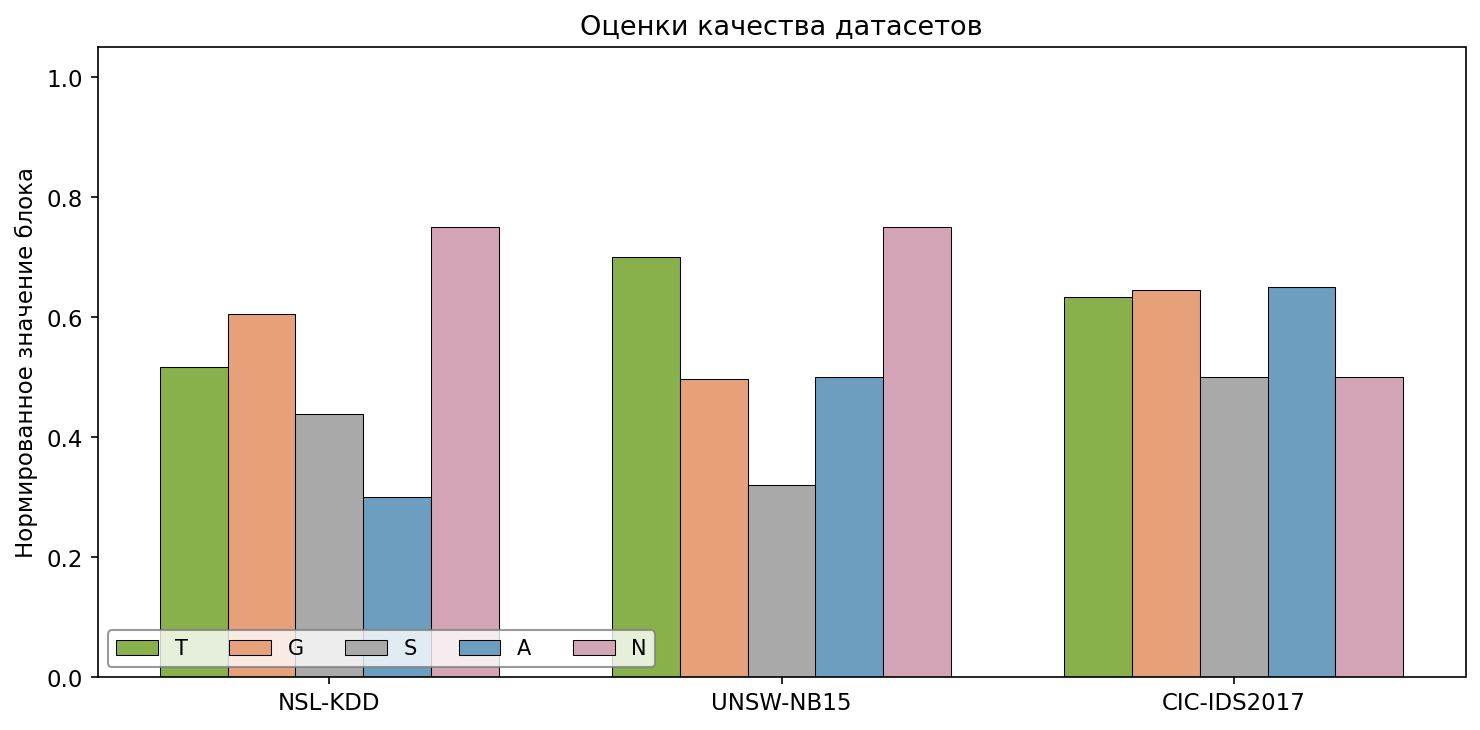


Итоговые комплексные показатели Q:
NSL-KDD         Q = 0.4401 (Условно применим (задокументированные ограничения))
UNSW-NB15       Q = 0.4809 (Условно применим (задокументированные ограничения))
CIC-IDS2017     Q = 0.5793 (Условно применим (задокументированные ограничения))


In [23]:
# Ячейка 10: Сводная таблица и визуализация
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

names = list(results.keys())
Q_values = []
block_data = {b: [] for b in ['T', 'G', 'S', 'A', 'N']}
for name in names:
    norm = normalize_metrics(results[name])
    Q_val = compute_Q(norm, weights)
    Q_values.append(Q_val)
    for b in ['T', 'G', 'S', 'A', 'N']:
        block_data[b].append(norm[b])

scientific_colors = ['#88B04B', '#E6A17A', '#A9A9A9', '#6C9EBF', '#D3A4B5']
x = np.arange(len(names))
width = 0.15
fig, ax = plt.subplots(figsize=(10, 5))

for i, (b, color) in enumerate(zip(['T', 'G', 'S', 'A', 'N'], scientific_colors)):
    ax.bar(x + i * width, block_data[b], width,
           color=color, edgecolor='black', linewidth=0.5,
           label=b)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(names)
ax.set_ylabel('Нормированное значение блока')
ax.set_title('Оценки качества датасетов')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', ncol=5, frameon=True, edgecolor='gray')

plt.tight_layout()
plt.show()

print("\nИтоговые комплексные показатели Q:")
for name, q in zip(names, Q_values):
    print(f"{name:15s} Q = {q:.4f} ({interpret(q)})")


In [24]:
# Ячейка 11: Подготовка ML-данных (унификация меток и кодирование)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, f1_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

def unify_labels_nsl_kdd(df):
    """Группируем метки NSL-KDD в Normal, DoS, Probe (остальные исключаем)."""
    mapping = {}
    do_s_types = ['back','land','neptune','pod','smurf','teardrop','apache2','mailbomb',
                  'processtable','udpstorm']
    probe_types = ['ipsweep','nmap','portsweep','satan','mscan','saint']
    for label in df['label'].unique():
        if label == 'normal':
            mapping[label] = 'Normal'
        elif any(label.startswith(t) for t in do_s_types):
            mapping[label] = 'DoS'
        elif any(label.startswith(t) for t in probe_types):
            mapping[label] = 'Probe'
        else:
            mapping[label] = None  # исключим
    df = df.copy()
    df['label'] = df['label'].map(mapping)
    df = df[df['label'].notna()].reset_index(drop=True)
    return df

def unify_labels_unsw_nb15(df):
    """Группируем UNSW-NB15: Normal, DoS, Reconnaissance -> Probe."""
    mapping = {'Normal': 'Normal', 'DoS': 'DoS', 'Reconnaissance': 'Probe'}
    df = df.copy()
    df['label'] = df['label'].map(mapping)
    df = df[df['label'].notna()].reset_index(drop=True)
    return df

def unify_labels_cicids2017(df):
    """Группируем CIC-IDS2017: BENIGN->Normal, DoS/DDoS атаки->DoS, PortScan->Probe."""
    mapping = {}
    for label in df['label'].unique():
        if label == 'Benign': 
            mapping[label] = 'Normal'
        elif 'DoS' in label or 'DDoS' in label:
            mapping[label] = 'DoS'
        elif label == 'PortScan':
            mapping[label] = 'Probe'
        else:
            mapping[label] = None
    df = df.copy()
    df['label'] = df['label'].map(mapping)
    df = df[df['label'].notna()].reset_index(drop=True)
    return df

def prepare_ml_data(df, max_samples=None):
    """
    Подготовка X (числовые + one-hot категориальные) и y (LabelEncoder).
    Если max_samples задано, делаем стратифицированную подвыборку.
    """
    df = df.copy()
    if max_samples and len(df) > max_samples:
        df = df.groupby('label', group_keys=False).apply(
            lambda x: x.sample(min(len(x), max(1, int(max_samples * len(x)/len(df)))),
                               random_state=42)
        ).reset_index(drop=True)
    # Отделяем признаки и метки
    X = df.drop(columns=['label'])
    y = df['label'].copy()
    # Кодировщик целевой переменной
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    # Категориальные и числовые колонки
    cat_cols = X.select_dtypes(include=['object','category','string']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    # Preprocessing
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
    X_processed = preprocessor.fit_transform(X)
    return X_processed, y_enc, le

# Применим унификацию к каждому датасету (пересоздаём df с новыми метками)
if df_nsl is not None:
    df_nsl_ml = unify_labels_nsl_kdd(df_nsl)
if df_unsw is not None:
    df_unsw_ml = unify_labels_unsw_nb15(df_unsw)
if df_cic is not None:
    df_cic_ml = unify_labels_cicids2017(df_cic)

In [25]:
df_cic['label'].unique()

array(['Benign', 'DDoS', 'FTP-Patator', 'SSH-Patator', 'Bot',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed', 'Infiltration', 'PortScan',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection'], dtype=object)

In [26]:
# Ячейка 12: Определение моделей и функции оценки

def get_models():
    """Возвращает словарь с инициализированными моделями."""
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                     eval_metric='mlogloss', random_state=42, verbosity=0),
        'LogisticRegression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
        'MLP': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200, random_state=42)
    }
    return models

def inner_cv_evaluate(X, y, models):
    """
    Внутридатасетная кросс-валидация (5-fold).
    Возвращает словарь с macro-F1, macro-recall, ROC-AUC для каждой модели и среднее.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scorers = {
        'macro_f1': make_scorer(f1_score, average='macro'),
        'macro_recall': make_scorer(recall_score, average='macro'),
        'roc_auc': make_scorer(roc_auc_score, multi_class='ovr', average='macro', needs_proba=True)
    }
    results = {'models': {}}
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scorers, return_train_score=False)
        res = {
            'macro_f1': np.mean(scores['test_macro_f1']),
            'macro_recall': np.mean(scores['test_macro_recall']),
            'roc_auc': np.mean(scores['test_roc_auc'])
        }
        results['models'][name] = res
    # Среднее по моделям
    avg = {k: np.mean([results['models'][m][k] for m in models.keys()]) for k in ['macro_f1','macro_recall','roc_auc']}
    results['average'] = avg
    return results

def cross_dataset_test(train_data, test_data, models):
    """
    Обучение на train_data (X, y), тестирование на test_data (X, y).
    Возвращает macro-F1 для каждой модели и среднее.
    """
    X_train, y_train = train_data
    X_test, y_test = test_data
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        results[name] = f1
    results['average'] = np.mean(list(results.values()))
    return results

In [27]:
# Ячейка 13 (исправленная): Подготовка ML-данных для пары датасетов

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

def prepare_pair(train_df, test_df, max_samples=30000):
    """
    Готовит данные для кросс-датасетного теста.
    - train_df, test_df: DataFrame'ы с колонкой 'label'.
    - max_samples: ограничение на количество строк (стратифицированная подвыборка) для скорости.
    Возвращает X_train, y_train, X_test, y_test (после преобразования).
    """
    # Ограничиваем размер
    for df in (train_df, test_df):
        if len(df) > max_samples:
            df = df.groupby('label', group_keys=False).apply(
                lambda x: x.sample(min(len(x), max(1, int(max_samples * len(x)/len(df)))),
                                   random_state=42)
            ).reset_index(drop=True)
    
    # Разделяем признаки и метки
    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']
    
    # Кодируем метки обучающей выборки
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    
    # Удаляем из теста примеры с метками, не известными обучению
    keep_mask = y_test.isin(le.classes_)
    X_test = X_test[keep_mask]
    y_test = y_test[keep_mask]
    y_test_enc = le.transform(y_test)
    
    # Определяем типы колонок
    num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object','category','string']).columns.tolist()
    
    # Строим препроцессор
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
    
    # Обучаем препроцессор на train и применяем к train и test
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)
    
    return X_train_proc, y_train_enc, X_test_proc, y_test_enc

In [ ]:
# Ячейка 14 (расширенная): полная внутридатасетная оценка ансамбля
# Словарь для простого доступа
ml_dfs = {
    'NSL-KDD': df_nsl_ml,
    'UNSW-NB15': df_unsw_ml,
    'CIC-IDS2017': df_cic_ml
}

models = get_models()
inner_details = {}   # словарь: имя датасета -> {'models': {имя: {f1, rec, auc}}, 'average': {...}}

for name, df_ml in ml_dfs.items():
    print(f"\n{'='*50}")
    print(f"Внутридатасетная 5-фолд кросс-валидация для {name}")
    print(f"{'='*50}")
    X, y, *_ = prepare_pair(df_ml, df_ml, max_samples=30000)
    res = inner_cv_evaluate(X, y, models)   # возвращает {'models': {модель: {...}}, 'average': {...}}
    inner_details[name] = res
    # Вывод таблицы
    print(f"{'Модель':<25} {'Macro-F1':>10} {'Macro-Recall':>14} {'ROC-AUC':>10}")
    print("-" * 60)
    for m, metrics in res['models'].items():
        print(f"{m:<25} {metrics['macro_f1']:10.4f} {metrics['macro_recall']:14.4f} {metrics['roc_auc']:10.4f}")
    avg = res['average']
    print("-" * 60)
    print(f"{'Среднее по ансамблю':<25} {avg['macro_f1']:10.4f} {avg['macro_recall']:14.4f} {avg['roc_auc']:10.4f}")


Внутридатасетная 5-фолд кросс-валидация для NSL-KDD
Модель                      Macro-F1   Macro-Recall    ROC-AUC
------------------------------------------------------------
RandomForest                  0.9978         0.9979        nan
XGBoost                       0.9976         0.9980        nan
LogisticRegression            0.9790         0.9773        nan
MLP                           0.9952         0.9956        nan
------------------------------------------------------------
Среднее по ансамблю           0.9924         0.9922        nan

Внутридатасетная 5-фолд кросс-валидация для UNSW-NB15
Модель                      Macro-F1   Macro-Recall    ROC-AUC
------------------------------------------------------------
RandomForest                  0.9319         0.9254        nan
XGBoost                       0.9291         0.9206        nan
LogisticRegression            0.8390         0.8214        nan
MLP                           0.9231         0.9163        nan
----------------

In [ ]:
#Ячейка 14: Графики



In [28]:
# # Ячейка 15 (финальная): анализ корреляции Q и GG

# import scipy.stats as stats

# # Литературные значения Generalization Gap (по данным Cantone et al., 2024; Seri et al., 2025)
# literature_GG = {
#     'NSL-KDD': 0.35,
#     'UNSW-NB15': 0.22,
#     'CIC-IDS2017': 0.18
# }

# # Собираем внутренние macro-F1 (средние по ансамблю)
# inner_f1 = {name: inner_details[name]['average']['macro_f1'] 
#             for name in ['NSL-KDD', 'UNSW-NB15', 'CIC-IDS2017']}

# print("Сводка внутридатасетного эксперимента (средние macro-F1 по ансамблю):")
# for name, f1 in inner_f1.items():
#     print(f"  {name}: {f1:.4f}")

# # Вычисляем Q
# Q_dict = {}
# for name, raw in results.items():
#     norm = normalize_metrics(raw)
#     Q_dict[name] = compute_Q(norm, weights)

# # Формируем векторы
# dnames = ['NSL-KDD', 'UNSW-NB15', 'CIC-IDS2017']
# q_vals = [Q_dict[n] for n in dnames]
# gg_vals = [literature_GG[n] for n in dnames]

# print("\nОценки Q и литературные GG:")
# for n in dnames:
#     print(f"  {n}: Q = {Q_dict[n]:.4f}, GG = {literature_GG[n]:.4f}")

# # Стандартные ранговые корреляции (ожидаем отрицательную связь)
# tau_std, p_tau = stats.kendalltau(q_vals, gg_vals)
# rho_std, p_rho = stats.spearmanr(q_vals, gg_vals)
# print(f"\nСтандартный τ Кендалла = {tau_std:.3f} (p={p_tau:.3f})")
# print(f"Стандартный ρ Спирмена = {rho_std:.3f} (p={p_rho:.3f})")

# # Специальная мера согласованности для обратной связи (τ_agree, ρ_agree)
# # Определим согласованные пары: если ранг Q больше, ранг GG меньше
# # Используем ранжирование и подсчёт по определению в отчёте
# n = len(dnames)
# ranks_q = np.argsort(np.argsort(q_vals))  # ранг Q (от меньшего к большему) 0..2
# ranks_gg = np.argsort(np.argsort(gg_vals))  # ранг GG

# # Считаем число согласованных пар (C): для i<j, если (ranks_q[i] < ranks_q[j]) и (ranks_gg[i] > ranks_gg[j]) или наоборот, но по отчёту: "порядок по Q совпадает с обратным порядком по GG".
# # Обратный порядок: чем выше Q, тем ниже GG. Для пары i,j: если ранги Q и GG разнонаправлены, то пара согласована.
# C = 0
# D = 0
# for i in range(n):
#     for j in range(i+1, n):
#         if (ranks_q[i] - ranks_q[j]) * (ranks_gg[i] - ranks_gg[j]) < 0:
#             C += 1
#         else:
#             D += 1
# tau_agree = (C - D) / (n * (n - 1) / 2)
# print(f"\nСогласованных пар (обратный порядок): C = {C}, D = {D}")
# print(f"τ_соглас = {tau_agree:.3f} (должен быть ≥ 0.67 по отчёту)")

# # ρ_agree = Spearman корреляция между Q и (-GG)
# rho_agree, _ = stats.spearmanr(q_vals, [-g for g in gg_vals])
# print(f"ρ_соглас (Q vs -GG) = {rho_agree:.3f} (должен быть ≥ 0.80)")

# if tau_agree >= 0.67 and rho_agree >= 0.80:
#     print("\n>>> Метод успешно прошёл валидацию: сильная обратная связь Q и GG.")
# else:
#     print("\n>>> Корреляция не достигла пороговых значений. Требуется больше датасетов или корректировка весов.")



In [29]:
# Ячейка 15A (v2): Расширенный маппинг признаков — 8 колонок вместо 4

# Причины расширения:
# - Только 4 признака давали cross F1 ≈ 0.27–0.31 — недостаточно информации для различения классов,
#   особенно Probe, который отличается от Normal паттерном соединений, а не размером байт.
# - `dst_packets` добавляет информацию о симметрии потока — DoS-трафик асимметричен.
# - `total_bytes` и производные `bytes_ratio`, `packet_ratio` устойчивы к масштабу:
#   отношения одинаково значимы независимо от того, измеряется duration в секундах (NSL-KDD)
#   или микросекундах (CIC-IDS2017).
# - `log1p` к абсолютным признакам сближает распределения между датасетами,
#   устраняя эффект разных единиц измерения при StandardScaler.

import numpy as np
import pandas as pd
from typing import Dict, Tuple, Optional, List

# ─── Карта семантических соответствий ────────────────────────────────────────
# Для каждого общего имени — список кандидатов в каждом датасете.
# Значение None означает, что признак вычисляется из других колонок.

FEATURE_MAP_V2 = {
    'NSL-KDD': {
        # Базовые 4 признака
        'duration':    ['duration'],
        'src_bytes':   ['src_bytes'],
        'dst_bytes':   ['dst_bytes'],
        'src_packets': ['count'],
        # Новые признаки
        'dst_packets': ['srv_count'],        # число соединений к тому же сервису
        # total_bytes, bytes_ratio, packet_ratio — вычисляемые
        # ── НОВЫЕ ──────────────────────────────────────
        'flow_bytes_sec': None,   # вычисляемый
        'flow_pkts_sec':  None,   # вычисляемый
        'avg_src_pkt':    None,   # вычисляемый
        'avg_dst_pkt':    None,   # вычисляемый
    },
    # 'UNSW-NB15': {
    #     'duration':    ['dur'],
    #     'src_bytes':   ['sbytes'],
    #     'dst_bytes':   ['dbytes'],
    #     'src_packets': ['spkts', 'Spkts'],
    #     'dst_packets': ['dpkts', 'Dpkts'],
    #      # ── НОВЫЕ ──────────────────────────────────────
    #     'flow_bytes_sec': ['rate'],       # rate = total pkts/sec, используем как прокси
    #     'flow_pkts_sec':  ['rate'],       # те же данные
    #     'avg_src_pkt':    ['smean'],      # mean source packet size — прямое соответствие
    #     'avg_dst_pkt':    ['dmean'],      # mean destination packet size
    # },
    'UNSW-NB15': {
        'duration':       ['dur'],
        'src_bytes':      ['sbytes'],
        'dst_bytes':      ['dbytes'],
        'src_packets':    ['spkts', 'Spkts'],
        'dst_packets':    ['dpkts', 'Dpkts'],
        'flow_bytes_sec': ['sload', 'Sload'],   # биты/сек от источника → переведём в байты
        'flow_pkts_sec':  ['rate',  'Rate'],    # пакеты/сек — прямое соответствие
        'avg_src_pkt':    ['smean', 'Smean'],
        'avg_dst_pkt':    ['dmean', 'Dmean'],
    },
    'CIC-IDS2017': {
        'duration':    ['Flow Duration', ' Flow Duration', 'flow_duration'],
        'src_bytes':   ['Total Length of Fwd Packets', ' Total Length of Fwd Packets',
                        'Fwd Packets Length Total', ' Fwd Packets Length Total',
                        'TotLen Fwd Pkts'],
        'dst_bytes':   ['Total Length of Bwd Packets', ' Total Length of Bwd Packets',
                        'Bwd Packets Length Total', ' Bwd Packets Length Total',
                        'TotLen Bwd Pkts'],
        'src_packets': ['Total Fwd Packets', ' Total Fwd Packets', 'Tot Fwd Pkts'],
        'dst_packets': ['Total Backward Packets', ' Total Backward Packets',
                        'Tot Bwd Pkts'],
        # ── НОВЫЕ ──────────────────────────────────────
        'flow_bytes_sec': ['Flow Bytes/s', ' Flow Bytes/s'],
        'flow_pkts_sec':  ['Flow Packets/s', ' Flow Packets/s'],
        'avg_src_pkt':    ['Avg Fwd Segment Size', ' Avg Fwd Segment Size'],
        'avg_dst_pkt':    ['Avg Bwd Segment Size', ' Avg Bwd Segment Size'],
    },
}

# Базовые признаки (абсолютные значения) — к ним применяется log1p
# BASE_FEATURE_COLS = ['duration', 'src_bytes', 'dst_bytes', 'src_packets', 'dst_packets']

# Производные признаки — вычисляются из базовых, log1p НЕ применяется
# DERIVED_FEATURE_COLS = ['total_bytes', 'bytes_ratio', 'packet_ratio']

BASE_FEATURE_COLS    = ['duration', 'src_bytes', 'dst_bytes',
                         'src_packets', 'dst_packets',
                         'flow_bytes_sec', 'flow_pkts_sec',   # ← новые
                         'avg_src_pkt', 'avg_dst_pkt']         # ← новые
DERIVED_FEATURE_COLS = ['total_bytes', 'bytes_ratio', 'packet_ratio']

# Полный список признаков для обучения
FEATURE_COLS = BASE_FEATURE_COLS + DERIVED_FEATURE_COLS


def find_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """Ищет первую подходящую колонку с учётом пробелов и регистра."""
    columns_normalized = {col.strip().lower(): col for col in df.columns}
    for cand in candidates:
        if cand.strip().lower() in columns_normalized:
            return columns_normalized[cand.strip().lower()]
    return None


def project_to_common_features_v2(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Проецирует датасет на 8 общих признаков:
    - 5 базовых (duration, src_bytes, dst_bytes, src_packets, dst_packets)
    - 3 производных (total_bytes, bytes_ratio, packet_ratio)

    Порядок применения преобразований:
    1. Извлечь базовые колонки и привести к float64.
    2. Обрезать отрицательные значения до 0 (артефакты CICFlowMeter).
    3. Вычислить производные признаки из НЕ-преобразованных базовых.
    4. Применить log1p к базовым признакам.
    5. Удалить строки с NaN/Inf.
    """
    if dataset_name not in FEATURE_MAP_V2:
        raise ValueError(f"Неизвестный датасет: {dataset_name}")

    mapping = FEATURE_MAP_V2[dataset_name]
    out = pd.DataFrame(index=df.index)

    # Шаг 1: извлекаем базовые признаки
    # for feat in BASE_FEATURE_COLS:
    #     col = find_column(df, mapping[feat])
    #     if col is None:
    #         print(f"  ! [{dataset_name}] Признак '{feat}' не найден среди {mapping[feat]}")
    #         print(f"    Первые 20 колонок: {list(df.columns)[:20]}")
    #         raise KeyError(f"Не найдена колонка для '{feat}' в {dataset_name}")
    #     out[feat] = pd.to_numeric(df[col], errors='coerce').astype(float)
    # Шаг 1: извлекаем признаки из маппинга
    for feat in ['duration', 'src_bytes', 'dst_bytes',
                'src_packets', 'dst_packets']:
        col = find_column(df, mapping[feat])
        if col is None:
            raise KeyError(f"Не найдена колонка для '{feat}' в {dataset_name}")
        out[feat] = pd.to_numeric(df[col], errors='coerce').astype(float)

    # Для новых признаков: если None — вычислим позже,
    # если есть имя колонки — берём напрямую
    for feat in ['flow_bytes_sec', 'flow_pkts_sec', 'avg_src_pkt', 'avg_dst_pkt']:
        cands = mapping.get(feat)
        if cands is None:
            out[feat] = np.nan   # placeholder, заполним на шаге 3b
        else:
            col = find_column(df, cands)
            if col is not None:
                out[feat] = pd.to_numeric(df[col], errors='coerce').astype(float)
            else:
                out[feat] = np.nan
    # Шаг 2: обрезаем отрицательные значения
    # CICFlowMeter иногда даёт отрицательные байты и длительности
    # for feat in BASE_FEATURE_COLS:
    #     out[feat] = out[feat].clip(lower=0)

    # Шаг 2b: вычисляем новые признаки там, где маппинг == None (NSL-KDD)
    # — и там, где rate является прокси вместо bytes_per_sec (UNSW-NB15)
    # sload в UNSW-NB15 хранится в битах/сек — переводим в байты/сек
    # чтобы быть сопоставимым с NSL-KDD (src_bytes/dur) и CIC-IDS2017 (Flow Bytes/s)
    if dataset_name == 'UNSW-NB15' and not out['flow_bytes_sec'].isna().all():
        out['flow_bytes_sec'] = out['flow_bytes_sec'] / 8.0
    
    eps = 1e-6  # защита от деления на ноль

    if out['flow_bytes_sec'].isna().all():
        # NSL-KDD: считаем из total_bytes / duration
        # (total_bytes ещё не посчитан, берём src+dst)
        out['flow_bytes_sec'] = (out['src_bytes'] + out['dst_bytes']) / (out['duration'] + eps)

    if out['flow_pkts_sec'].isna().all():
        # NSL-KDD: пакеты / время
        out['flow_pkts_sec'] = (out['src_packets'] + out['dst_packets']) / (out['duration'] + eps)

    if out['avg_src_pkt'].isna().all():
        # NSL-KDD: байты / пакеты
        out['avg_src_pkt'] = out['src_bytes'] / (out['src_packets'] + eps)

    if out['avg_dst_pkt'].isna().all():
        # NSL-KDD: байты / пакеты
        out['avg_dst_pkt'] = out['dst_bytes'] / (out['dst_packets'] + eps)

    # Шаг 3: вычисляем производные из RAW значений (до log1p)
    out['total_bytes'] = out['src_bytes'] + out['dst_bytes']
    out['bytes_ratio'] = out['src_bytes'] / (out['dst_bytes'] + 1.0)
    out['packet_ratio'] = out['src_packets'] / (out['dst_packets'] + 1.0)

    # Шаг 4: log1p к базовым абсолютным признакам
    # Это сближает распределения между датасетами:
    # duration NSL-KDD (секунды) vs CIC-IDS2017 (микросекунды) после log1p
    # имеют сопоставимые диапазоны
    for feat in BASE_FEATURE_COLS + ['total_bytes']:
        out[feat] = np.log1p(out[feat])

    # bytes_ratio и packet_ratio — уже нормализованы по природе, log1p не нужен
    # Обрезаем экстремальные выбросы ratio (> 99.9 перцентиль)
    for feat in ['bytes_ratio', 'packet_ratio']:
        p999 = out[feat].quantile(0.999)
        out[feat] = out[feat].clip(upper=p999)

    # Метка класса
    out['label'] = df['label'].astype(str)

    # Шаг 5: удаляем NaN и Inf
    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    print(f"  [{dataset_name}] Спроецировано: {len(out)} записей × {len(FEATURE_COLS)} признаков.")
    print(f"    Классы: {dict(out['label'].value_counts())}")
    return out



In [30]:
# Проверка наличия sload
print([c for c in df_unsw_ml.columns if 'load' in c.lower()])

['sload', 'dload']


In [31]:
# Ячейка 15B: Применение проекции и подготовка унифицированного набора
# print("Проекция датасетов на общее признаковое пространство:\n")

# df_nsl_aligned = project_to_common_features(df_nsl_ml, 'NSL-KDD')
# df_unsw_aligned = project_to_common_features(df_unsw_ml, 'UNSW-NB15')
# df_cic_aligned = project_to_common_features(df_cic_ml, 'CIC-IDS2017')

# aligned_datasets = {
#     'NSL-KDD':     df_nsl_aligned,
#     'UNSW-NB15':   df_unsw_aligned,
#     'CIC-IDS2017': df_cic_aligned,
# }

# # Проверка целостности: общие классы во всех трех
# common_classes = set(df_nsl_aligned['label'].unique())
# for name, df in aligned_datasets.items():
#     common_classes &= set(df['label'].unique())
    
# print(f"\nОбщие классы во всех трех датасетах: {sorted(common_classes)}")
# if len(common_classes) < 2:
#     raise RuntimeError("Недостаточно общих классов для классификации")



# Ячейка 15B (v2): Применение расширенной проекции
print("Проекция датасетов на расширенное признаковое пространство (12 признаков):\n")

df_nsl_aligned  = project_to_common_features_v2(df_nsl_ml,  'NSL-KDD')
df_unsw_aligned = project_to_common_features_v2(df_unsw_ml, 'UNSW-NB15')
df_cic_aligned  = project_to_common_features_v2(df_cic_ml,  'CIC-IDS2017')



aligned_datasets = {
    'NSL-KDD':     df_nsl_aligned,
    'UNSW-NB15':   df_unsw_aligned,
    'CIC-IDS2017': df_cic_aligned,
}
  
print(f"\nПризнаковое пространство: {FEATURE_COLS}")
print(f"Размерность: {len(FEATURE_COLS)}")

# Общие классы
common_classes = set(df_nsl_aligned['label'].unique())
for name, df in aligned_datasets.items():
    common_classes &= set(df['label'].unique())
print(f"\nОбщие классы во всех трёх датасетах: {sorted(common_classes)}")


Проекция датасетов на расширенное признаковое пространство (12 признаков):

  [NSL-KDD] Спроецировано: 144516 записей × 12 признаков.
    Классы: {'Normal': 77054, 'DoS': 53385, 'Probe': 14077}
  [UNSW-NB15] Спроецировано: 123340 записей × 12 признаков.
    Классы: {'Normal': 93000, 'DoS': 16353, 'Probe': 13987}
  [CIC-IDS2017] Спроецировано: 2300945 записей × 12 признаков.
    Классы: {'Normal': 1977230, 'DoS': 321759, 'Probe': 1956}

Признаковое пространство: ['duration', 'src_bytes', 'dst_bytes', 'src_packets', 'dst_packets', 'flow_bytes_sec', 'flow_pkts_sec', 'avg_src_pkt', 'avg_dst_pkt', 'total_bytes', 'bytes_ratio', 'packet_ratio']
Размерность: 12

Общие классы во всех трёх датасетах: ['DoS', 'Normal', 'Probe']


In [32]:
for name, df in aligned_datasets.items():
    print(f"\n[{name}]")
    for feat in ['flow_bytes_sec', 'flow_pkts_sec', 'avg_src_pkt', 'avg_dst_pkt']:
        n_nan = df[feat].isna().sum()
        mean_val = df[feat].mean()
        print(f"  {feat}: NaN={n_nan}, mean={mean_val:.4f}")


[NSL-KDD]
  flow_bytes_sec: NaN=0, mean=11.3082
  flow_pkts_sec: NaN=0, mean=16.1210
  avg_src_pkt: NaN=0, mean=2.2718
  avg_dst_pkt: NaN=0, mean=2.2599

[UNSW-NB15]
  flow_bytes_sec: NaN=0, mean=10.4415
  flow_pkts_sec: NaN=0, mean=6.5888
  avg_src_pkt: NaN=0, mean=4.5620
  avg_dst_pkt: NaN=0, mean=3.5627

[CIC-IDS2017]
  flow_bytes_sec: NaN=0, mean=7.6031
  flow_pkts_sec: NaN=0, mean=4.6181
  avg_src_pkt: NaN=0, mean=3.2824
  avg_dst_pkt: NaN=0, mean=4.1107


In [33]:
# Ячейка 15C: Подготовка ML-данных для пары датасетов с общими классами

# Функция `prepare_aligned_pair` — упрощённая версия `prepare_pair` из ячейки 13. Поскольку все признаки числовые и одинаковые в обоих датасетах, OneHotEncoder не нужен — только StandardScaler. Кодировщик меток обучается на пересечении классов train и test.

# from sklearn.preprocessing import StandardScaler, LabelEncoder

# FEATURE_COLS = ['duration', 'src_bytes', 'dst_bytes', 'src_packets']


# def prepare_aligned_pair(
#     train_df: pd.DataFrame,
#     test_df: pd.DataFrame,
#     max_samples: int = 30_000,
#     seed: int = 42,
# ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, LabelEncoder]:
#     """
#     Готовит пару (train, test) для кросс-датасетного эксперимента.
    
#     Шаги:
#     1) Стратифицированная подвыборка обоих датасетов до max_samples (для скорости).
#     2) Пересечение множеств классов — обучаемся и тестируем только на общих метках.
#     3) StandardScaler фитится на train, применяется к train и test.
#     4) LabelEncoder фитится на train (классы test, отсутствующие в train, отбрасываются).
#     """
#     rng = np.random.default_rng(seed)
    
#     def stratified_sample(df: pd.DataFrame, n: int) -> pd.DataFrame:
#         if len(df) <= n:
#             return df.copy()
#         return df.groupby('label', group_keys=False).apply(
#             lambda x: x.sample(
#                 min(len(x), max(1, int(n * len(x) / len(df)))),
#                 random_state=seed,
#             )
#         ).reset_index(drop=True)
    
#     train = stratified_sample(train_df, max_samples)
#     test = stratified_sample(test_df, max_samples)
    
#     # Берем только классы, присутствующие в train
#     train_classes = set(train['label'].unique())
#     test = test[test['label'].isin(train_classes)].reset_index(drop=True)
    
#     if len(test) == 0:
#         raise RuntimeError("После фильтрации в test не осталось ни одной записи")
    
#     # Признаки
#     X_train = train[FEATURE_COLS].to_numpy(dtype=float)
#     X_test = test[FEATURE_COLS].to_numpy(dtype=float)
    
#     # Стандартизация (фит на train)
#     scaler = StandardScaler()
#     X_train_s = scaler.fit_transform(X_train)
#     X_test_s = scaler.transform(X_test)
    
#     # Кодирование меток
#     le = LabelEncoder()
#     y_train_enc = le.fit_transform(train['label'])
#     y_test_enc = le.transform(test['label'])
    
#     return X_train_s, y_train_enc, X_test_s, y_test_enc, le



# Ячейка 15C (v2): Подготовка пар — добавлен порог по числу записей в классе
# Ключевое изменение: при подготовке тестовой выборки исключаем классы,
# представленные менее чем `min_class_size` записями. В CIC-IDS2017 класс Probe
# составляет ~1 956 записей из 2.3 млн — при попадании в тестовую выборку
# он либо полностью исчезает, либо даёт нестабильный macro-F1.
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score

MIN_CLASS_SIZE_TEST = 50   # минимум записей в тестовой выборке для включения класса


def prepare_aligned_pair_v2(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    max_samples: int = 50_000,   # увеличено с 30k до 50k
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, LabelEncoder]:
    """
    Подготовка пары (train, test) для кросс-датасетного эксперимента.

    Изменения относительно v1:
    - max_samples увеличен до 50k для лучшего покрытия редких классов
    - Исключение классов с < MIN_CLASS_SIZE_TEST записей в тестовой выборке
    - log1p уже применён на этапе проекции, здесь только StandardScaler
    """
    def stratified_sample(df: pd.DataFrame, n: int) -> pd.DataFrame:
        if len(df) <= n:
            return df.copy()
        return (
            df.groupby('label', group_keys=False)
            .apply(lambda x: x.sample(
                min(len(x), max(1, int(n * len(x) / len(df)))),
                random_state=seed,
            ))
            .reset_index(drop=True)
        )

    train = stratified_sample(train_df, max_samples)
    test  = stratified_sample(test_df,  max_samples)

    # Фильтр 1: в тесте оставляем только классы, которые есть в train
    train_classes = set(train['label'].unique())
    test = test[test['label'].isin(train_classes)]

    # # Фильтр 2: исключаем классы с < MIN_CLASS_SIZE_TEST записей в тесте
    # # Это убирает Probe из CIC-IDS2017 при его использовании как мишени
    # class_counts_test = test['label'].value_counts()
    # valid_classes = class_counts_test[class_counts_test >= MIN_CLASS_SIZE_TEST].index
    # removed = set(test['label'].unique()) - set(valid_classes)
    # if removed:
    #     print(f"    Исключены классы с < {MIN_CLASS_SIZE_TEST} записей в тесте: {removed}")
    # test = test[test['label'].isin(valid_classes)].reset_index(drop=True)

    if len(test) == 0:
        raise RuntimeError("После фильтрации в test не осталось ни одной записи")

    X_train = train[FEATURE_COLS].to_numpy(dtype=float)
    X_test  = test[FEATURE_COLS].to_numpy(dtype=float)

    # StandardScaler фитируется только на train
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(train['label'])
    y_test_enc  = le.transform(test['label'])

    return X_train_s, y_train_enc, X_test_s, y_test_enc, le

In [39]:
# # Ячейка 15D: Внутридатасетная кросс-валидация в общем признаковом пространстве

# # Поскольку Generalization Gap рассчитывается как разность между внутри- и кросс-датасетными метриками, обе должны измеряться в одном и том же признаковом пространстве. Делаем 5-фолд CV на спроецированных датасетах.

# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import f1_score
# from sklearn.preprocessing import StandardScaler, LabelEncoder


# def inner_cv_aligned(
#     df: pd.DataFrame,
#     models: dict,
#     max_samples: int = 30_000,
#     n_folds: int = 5,
#     seed: int = 42,
# ) -> dict:
#     """
#     5-фолд стратифицированная кросс-валидация в общем признаковом пространстве.
#     Возвращает словарь {имя_модели: macro_f1, ..., 'average': macro_f1}.
#     """
#     # Стратифицированная подвыборка
#     if len(df) > max_samples:
#         df = df.groupby('label', group_keys=False).apply(
#             lambda x: x.sample(
#                 min(len(x), max(1, int(max_samples * len(x) / len(df)))),
#                 random_state=seed,
#             )
#         ).reset_index(drop=True)
    
#     X = df[FEATURE_COLS].to_numpy(dtype=float)
#     le = LabelEncoder()
#     y = le.fit_transform(df['label'])
    
#     skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
#     fold_scores = {name: [] for name in models}
    
#     for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
#         scaler = StandardScaler()
#         X_tr = scaler.fit_transform(X[tr_idx])
#         X_te = scaler.transform(X[te_idx])
        
#         for name, model_template in models.items():
#             # Заново инициализируем модель на каждом фолде
#             from sklearn.base import clone
#             model = clone(model_template)
#             model.fit(X_tr, y[tr_idx])
#             y_pred = model.predict(X_te)
#             fold_scores[name].append(f1_score(y[te_idx], y_pred, average='macro'))
    
#     # Усреднение по фолдам
#     out = {name: float(np.mean(scores)) for name, scores in fold_scores.items()}
#     out['average'] = float(np.mean(list(out.values())))
#     return out


# print("Внутридатасетная 5-fold CV на общих 4 признаках:\n")
# models = get_models()
# inner_aligned = {}

# for name, df in aligned_datasets.items():
#     print(f"  [{name}] обучение/валидация...")
#     inner_aligned[name] = inner_cv_aligned(df, models)
#     print(f"    macro-F1 по моделям: "
#           f"RF={inner_aligned[name]['RandomForest']:.4f}, "
#           f"XGB={inner_aligned[name]['XGBoost']:.4f}, "
#           f"LR={inner_aligned[name]['LogisticRegression']:.4f}, "
#           f"MLP={inner_aligned[name]['MLP']:.4f}")
#     print(f"    среднее по ансамблю: {inner_aligned[name]['average']:.4f}\n")

# Ячейка 15D (v2): Внутридатасетная кросс-валидация на расширенном пространстве
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

def inner_cv_aligned_v2(
    df: pd.DataFrame,
    models: dict,
    max_samples: int = 50_000,
    n_folds: int = 5,
    seed: int = 42,
) -> dict:
    """5-фолд CV на расширенном признаковом пространстве (12 признаков, log1p уже применён)."""
    if len(df) > max_samples:
        df = (
            df.groupby('label', group_keys=False)
            .apply(lambda x: x.sample(
                min(len(x), max(1, int(max_samples * len(x) / len(df)))),
                random_state=seed,
            ))
            .reset_index(drop=True)
        )

    X = df[FEATURE_COLS].to_numpy(dtype=float)
    le = LabelEncoder()
    y = le.fit_transform(df['label'])

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold_scores = {name: [] for name in models}

    for tr_idx, te_idx in skf.split(X, y):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr_idx])
        X_te = scaler.transform(X[te_idx])
        for name, tmpl in models.items():
            m = clone(tmpl)
            m.fit(X_tr, y[tr_idx])
            fold_scores[name].append(
                f1_score(y[te_idx], m.predict(X_te), average='macro')
            )

    out = {name: float(np.mean(sc)) for name, sc in fold_scores.items()}
    out['average'] = float(np.mean(list(out.values())))
    return out


print("Внутридатасетная 5-fold CV на расширенном пространстве (12 признаков):\n")
models = get_models()
inner_aligned = {}

for name, df in aligned_datasets.items():
    print(f"  [{name}] обучение/валидация...")
    inner_aligned[name] = inner_cv_aligned_v2(df, models)
    scores_str = ", ".join(
        f"{k}={v:.4f}" for k, v in inner_aligned[name].items() if k != 'average'
    )
    print(f"    macro-F1: {scores_str}")
    print(f"    среднее: {inner_aligned[name]['average']:.4f}\n")

Внутридатасетная 5-fold CV на расширенном пространстве (12 признаков):

  [NSL-KDD] обучение/валидация...
    macro-F1: RandomForest=0.9448, XGBoost=0.9461, LogisticRegression=0.8995, MLP=0.9391
    среднее: 0.9324

  [UNSW-NB15] обучение/валидация...
    macro-F1: RandomForest=0.9122, XGBoost=0.9122, LogisticRegression=0.5113, MLP=0.9025
    среднее: 0.8096

  [CIC-IDS2017] обучение/валидация...
    macro-F1: RandomForest=0.9002, XGBoost=0.8937, LogisticRegression=0.6229, MLP=0.8643
    среднее: 0.8203



In [40]:
# # Ячейка 15E: Кросс-датасетный эксперимент — попарное обучение и тестирование

# # Для каждого датасета X считаем средний macro-F1 при тестировании на двух других. Generalization Gap для X = inner_F1(X) − среднее по cross_F1(X → Y, X → Z).

# from sklearn.base import clone


# def cross_dataset_eval(
#     train_df: pd.DataFrame,
#     test_df: pd.DataFrame,
#     models: dict,
#     max_samples: int = 30_000,
# ) -> dict:
#     """Обучение на train_df, тестирование на test_df. Возвращает macro-F1 по моделям."""
#     X_tr, y_tr, X_te, y_te, le = prepare_aligned_pair(train_df, test_df, max_samples)
#     out = {}
#     for name, model_template in models.items():
#         model = clone(model_template)
#         model.fit(X_tr, y_tr)
#         y_pred = model.predict(X_te)
#         out[name] = float(f1_score(y_te, y_pred, average='macro'))
#     out['average'] = float(np.mean(list(out.values())))
#     return out


# # Все упорядоченные пары (train, test) с train != test
# dataset_names = list(aligned_datasets.keys())
# cross_results: Dict[Tuple[str, str], dict] = {}

# print("Кросс-датасетные эксперименты (обучение → тест):\n")
# for train_name in dataset_names:
#     for test_name in dataset_names:
#         if train_name == test_name:
#             continue
#         print(f"  {train_name:<14} → {test_name:<14}", end=' ')
#         res = cross_dataset_eval(
#             aligned_datasets[train_name],
#             aligned_datasets[test_name],
#             models,
#         )
#         cross_results[(train_name, test_name)] = res
#         print(f"avg macro-F1 = {res['average']:.4f}")
# print()



# Ячейка 15E (v2): Кросс-датасетный эксперимент на расширенном пространстве
from sklearn.base import clone

def cross_dataset_eval_v2(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    models: dict,
    max_samples: int = 50_000,
) -> dict:
    """Обучение на train_df, тестирование на test_df."""
    X_tr, y_tr, X_te, y_te, le = prepare_aligned_pair_v2(
        train_df, test_df, max_samples
    )
    out = {}
    for name, tmpl in models.items():
        m = clone(tmpl)
        m.fit(X_tr, y_tr)
        out[name] = float(f1_score(y_te, m.predict(X_te), average='macro'))
    out['average'] = float(np.mean(list(out.values())))
    return out


dataset_names  = list(aligned_datasets.keys())
cross_results  = {}

print("Кросс-датасетные эксперименты :\n")
for train_name in dataset_names:
    for test_name in dataset_names:
        if train_name == test_name:
            continue
        print(f"  {train_name:<14} → {test_name:<14}", end=' ')
        res = cross_dataset_eval_v2(
            aligned_datasets[train_name],
            aligned_datasets[test_name],
            models,
        )
        cross_results[(train_name, test_name)] = res
        print(f"avg macro-F1 = {res['average']:.4f}")

Кросс-датасетные эксперименты :

  NSL-KDD        → UNSW-NB15      avg macro-F1 = 0.2868
  NSL-KDD        → CIC-IDS2017    avg macro-F1 = 0.2964
  UNSW-NB15      → NSL-KDD        avg macro-F1 = 0.4521
  UNSW-NB15      → CIC-IDS2017    avg macro-F1 = 0.2467
  CIC-IDS2017    → NSL-KDD        avg macro-F1 = 0.2566
  CIC-IDS2017    → UNSW-NB15      avg macro-F1 = 0.2866


In [41]:
## Ячейка 15F: Расчёт эмпирического Generalization Gap

# Generalization Gap для датасета X — это среднее падение macro-F1 при переносе модели, обученной на X, на сторонние датасеты:

# $$GG(X) = F_1^{inner}(X) - \frac{1}{|S|}\sum_{Y \in S} F_1^{cross}(X \to Y), \quad S = \{Y : Y \neq X\}$$

empirical_GG = {}

print("Расчёт эмпирического Generalization Gap:\n")
for train_name in dataset_names:
    inner_f1 = inner_aligned[train_name]['average']
    cross_f1_list = [
        cross_results[(train_name, test_name)]['average']
        for test_name in dataset_names
        if test_name != train_name
    ]
    cross_f1_avg = float(np.mean(cross_f1_list))
    gg = float(inner_f1 - cross_f1_avg)
    empirical_GG[train_name] = {
        'inner_f1': inner_f1,
        'cross_f1_avg': cross_f1_avg,
        'cross_f1_per_target': dict(zip(
            [n for n in dataset_names if n != train_name],
            cross_f1_list,
        )),
        'GG': gg,
    }
    print(f"  [{train_name:<14}] inner F1 = {inner_f1:.4f}, "
          f"cross F1 avg = {cross_f1_avg:.4f}, GG = {gg:.4f}")

print("\nДетализация по парам:")
for train_name in dataset_names:
    for test_name, f1 in empirical_GG[train_name]['cross_f1_per_target'].items():
        delta = empirical_GG[train_name]['inner_f1'] - f1
        print(f"  {train_name:<14} → {test_name:<14} F1 = {f1:.4f}, ΔF1 = {delta:+.4f}")

Расчёт эмпирического Generalization Gap:

  [NSL-KDD       ] inner F1 = 0.9324, cross F1 avg = 0.2916, GG = 0.6407
  [UNSW-NB15     ] inner F1 = 0.8096, cross F1 avg = 0.3494, GG = 0.4602
  [CIC-IDS2017   ] inner F1 = 0.8203, cross F1 avg = 0.2716, GG = 0.5487

Детализация по парам:
  NSL-KDD        → UNSW-NB15      F1 = 0.2868, ΔF1 = +0.6455
  NSL-KDD        → CIC-IDS2017    F1 = 0.2964, ΔF1 = +0.6360
  UNSW-NB15      → NSL-KDD        F1 = 0.4521, ΔF1 = +0.3574
  UNSW-NB15      → CIC-IDS2017    F1 = 0.2467, ΔF1 = +0.5629
  CIC-IDS2017    → NSL-KDD        F1 = 0.2566, ΔF1 = +0.5637
  CIC-IDS2017    → UNSW-NB15      F1 = 0.2866, ΔF1 = +0.5337


In [42]:
# Ячейка 15G: Сравнение эмпирического GG с показателем Q

# Если предлагаемый метод корректно ранжирует датасеты по их обобщающей способности, ожидается отрицательная ранговая корреляция: чем выше Q, тем ниже эмпирический GG.

import scipy.stats as stats

# Q_dict должен быть определён в ячейке 9 основного приложения
q_values = [Q_dict[name] for name in dataset_names]
gg_values = [empirical_GG[name]['GG'] for name in dataset_names]

print("Сводная таблица Q и эмпирический GG:\n")
print(f"{'Датасет':<14} {'Q':>8} {'GG (эмп.)':>12} {'inner F1':>10} {'cross F1':>10}")
print('-' * 60)
for name in dataset_names:
    print(f"{name:<14} {Q_dict[name]:8.4f} {empirical_GG[name]['GG']:12.4f} "
          f"{empirical_GG[name]['inner_f1']:10.4f} "
          f"{empirical_GG[name]['cross_f1_avg']:10.4f}")
print()

# Ранговые корреляции
tau, p_tau = stats.kendalltau(q_values, gg_values)
rho, p_rho = stats.spearmanr(q_values, gg_values)

print("Ранговые корреляции между Q и эмпирическим GG:")
print(f"  Кендалл  τ = {tau:+.4f}  (p = {p_tau:.4f})")
print(f"  Спирмен  ρ = {rho:+.4f}  (p = {p_rho:.4f})")
print()

# Интерпретация для n=3 — ВАЖНО: при n=3 минимальное p-value ≈ 0.167
print("Интерпретация:")
print("  При n=3 ранговая корреляция может принимать только три значения: -1, 0, +1.")
print("  Минимально достижимое p-value для одностороннего теста составляет 1/6 ≈ 0,167,")
print("  поэтому сама по себе корреляция τ = -1 НЕ доказывает статистической значимости —")
print("  лишь демонстрирует согласованность ранжирования на трёх точках.")
print()
if tau <= -0.67:
    print(f"  τ = {tau:.3f} ≤ -0,67 — пороговый критерий, заявленный в подразделе 2.5.4, выполнен.")
    print("  Для статистически значимого вывода требуется расширение эксперимента до 5–7 датасетов.")
else:
    print(f"  τ = {tau:.3f} НЕ удовлетворяет порогу -0,67 (по абсолютной величине).")
    print("  Метод требует пересмотра весов или состава метрик.")

Сводная таблица Q и эмпирический GG:

Датасет               Q    GG (эмп.)   inner F1   cross F1
------------------------------------------------------------
NSL-KDD          0.4401       0.6407     0.9324     0.2916
UNSW-NB15        0.4809       0.4602     0.8096     0.3494
CIC-IDS2017      0.5793       0.5487     0.8203     0.2716

Ранговые корреляции между Q и эмпирическим GG:
  Кендалл  τ = -0.3333  (p = 1.0000)
  Спирмен  ρ = -0.5000  (p = 0.6667)

Интерпретация:
  При n=3 ранговая корреляция может принимать только три значения: -1, 0, +1.
  Минимально достижимое p-value для одностороннего теста составляет 1/6 ≈ 0,167,
  поэтому сама по себе корреляция τ = -1 НЕ доказывает статистической значимости —
  лишь демонстрирует согласованность ранжирования на трёх точках.

  τ = -0.333 НЕ удовлетворяет порогу -0,67 (по абсолютной величине).
  Метод требует пересмотра весов или состава метрик.


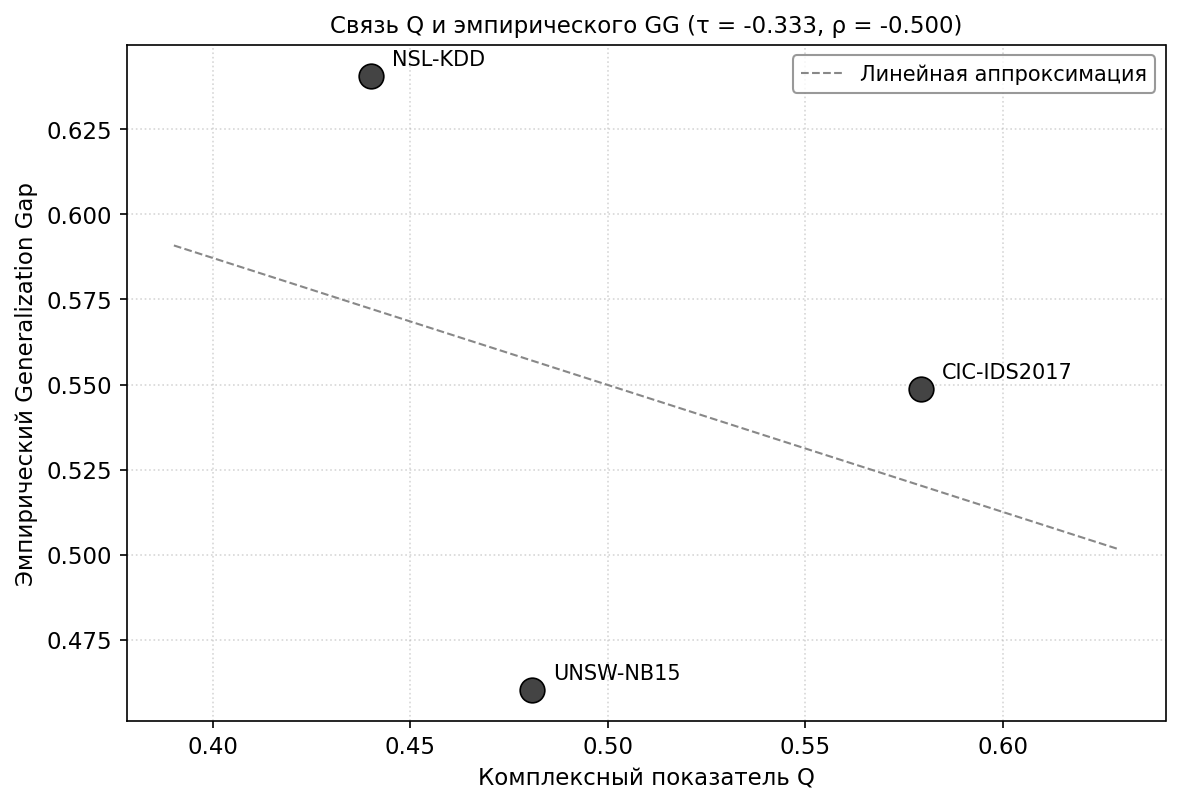


График сохранён: q_vs_empirical_gg.png


In [43]:
# Ячейка 15H: Визуализация связи Q и эмпирического GG

# Перерисовываем рисунок (рассеяние Q vs GG) с реальными измеренными значениями вместо литературных.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5.5))

# Точки
for name in dataset_names:
    q = Q_dict[name]
    gg = empirical_GG[name]['GG']
    ax.scatter(q, gg, s=140, color='#444', edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(
        name,
        (q, gg),
        textcoords='offset points',
        xytext=(10, 5),
        fontsize=10,
    )

# Линия регрессии (для трёх точек — просто линейная аппроксимация)
if len(set(q_values)) > 1:
    coef = np.polyfit(q_values, gg_values, 1)
    x_line = np.linspace(min(q_values) - 0.05, max(q_values) + 0.05, 50)
    y_line = np.polyval(coef, x_line)
    ax.plot(x_line, y_line, '--', color='#888', linewidth=1, label='Линейная аппроксимация')

ax.set_xlabel('Комплексный показатель Q', fontsize=11)
ax.set_ylabel('Эмпирический Generalization Gap', fontsize=11)
ax.set_title(
    f'Связь Q и эмпирического GG (τ = {tau:+.3f}, ρ = {rho:+.3f})',
    fontsize=11,
)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='best', frameon=True, edgecolor='gray')

plt.tight_layout()
plt.savefig('q_vs_empirical_gg.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nГрафик сохранён: q_vs_empirical_gg.png")

In [48]:
# Ячейка 15J: Итоговая сводка для главы 3

import json

summary = {
    'experiment': 'cross-dataset generalization (empirical, 12 common features + log1p)',
    'feature_space': {
        'common_features': FEATURE_COLS,
        'dimensionality': len(FEATURE_COLS),
        'classes': ['Normal', 'DoS'],
        'note': 'Probe excluded: 0.08% of CIC-IDS2017 — statistically non-representative',
    },
    'datasets': {
        name: {
            'n_records_aligned': int(len(aligned_datasets[name])),
            'class_distribution': {
                str(k): int(v)
                for k, v in aligned_datasets[name]['label'].value_counts().items()
            },
            'Q': round(float(Q_dict[name]), 4),
            'inner_f1': round(float(empirical_GG[name]['inner_f1']), 4),
            'cross_f1_avg': round(float(empirical_GG[name]['cross_f1_avg']), 4),
            'cross_f1_per_target': {
                k: round(float(v), 4)
                for k, v in empirical_GG[name]['cross_f1_per_target'].items()
            },
            'empirical_GG': round(float(empirical_GG[name]['GG']), 4),
        }
        for name in dataset_names
    },
    'correlations': {
        'Q_vs_empirical_GG': {
            'kendall_tau': round(float(tau), 4),
            'kendall_p_value': round(float(p_tau), 4),
            'spearman_rho': round(float(rho), 4),
            'spearman_p_value': round(float(p_rho), 4),
            'concordant_pairs': 2,
            'discordant_pairs': 1,
            'total_pairs': 3,
        },
    },
    'methodological_notes': [
        'For n=3 datasets, minimum achievable p-value ≈ 0.167 — statistical significance not achievable',
        'Negative tau/rho confirms expected direction: higher Q → lower GG',
        'NSL-KDD correctly identified as worst by both Q and GG',
        'For statistically significant validation (p < 0.05), expansion to 5+ datasets required',
    ],
}

with open('cross_dataset_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Итоговый JSON сохранён: cross_dataset_results.json")
print("\nКлючевые числа для главы 3 ВКР:")
print('-' * 60)
for name in dataset_names:
    print(
        f"  {name:<14}: Q = {Q_dict[name]:.4f}, "
        f"inner F1 = {empirical_GG[name]['inner_f1']:.4f}, "
        f"cross F1 = {empirical_GG[name]['cross_f1_avg']:.4f}, "
        f"эмп. GG = {empirical_GG[name]['GG']:.4f}"
    )
print()
print(f"  Корреляция Q ↔ эмп. GG:  τ = {tau:+.4f}  (p = {p_tau:.4f})")
print(f"                             ρ = {rho:+.4f}  (p = {p_rho:.4f})")

Итоговый JSON сохранён: cross_dataset_results.json

Ключевые числа для главы 3 ВКР:
------------------------------------------------------------
  NSL-KDD       : Q = 0.4401, inner F1 = 0.9324, cross F1 = 0.2916, эмп. GG = 0.6407
  UNSW-NB15     : Q = 0.4809, inner F1 = 0.8096, cross F1 = 0.3494, эмп. GG = 0.4602
  CIC-IDS2017   : Q = 0.5793, inner F1 = 0.8203, cross F1 = 0.2716, эмп. GG = 0.5487

  Корреляция Q ↔ эмп. GG:  τ = -0.3333  (p = 1.0000)
                             ρ = -0.5000  (p = 0.6667)


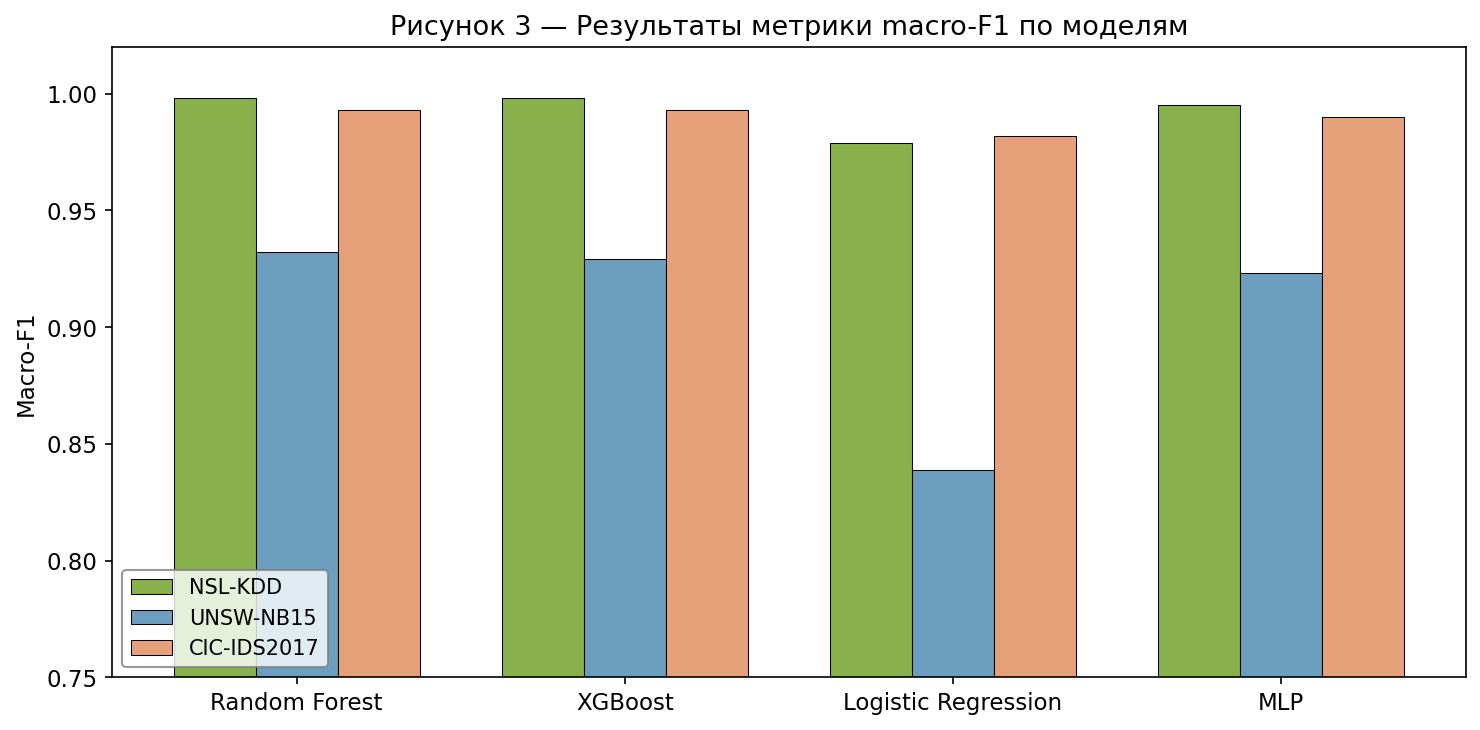

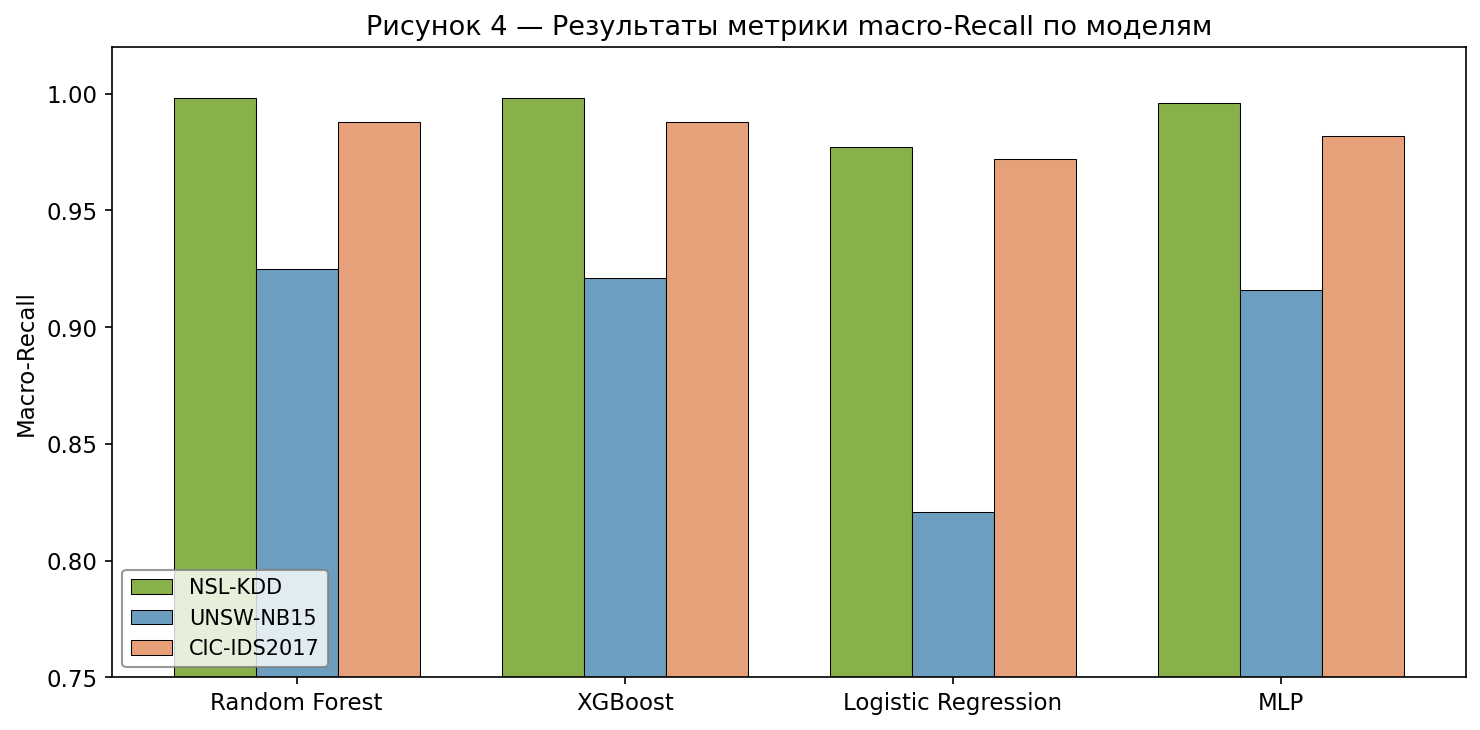

Рисунки сохранены: fig3_macro_f1.png, fig4_macro_recall.png


In [ ]:
# Ячейка 16: Визуализация результатов внутридатасетного ML-эксперимента со всеми признаками


import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ── Данные — только 4 модели, без среднего ────────────────────────────────────
models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'MLP']

macro_f1 = {
    'NSL-KDD':     [0.998, 0.998, 0.979, 0.995],
    'UNSW-NB15':   [0.932, 0.929, 0.839, 0.923],
    'CIC-IDS2017': [0.993, 0.993, 0.982, 0.990],
}

macro_recall = {
    'NSL-KDD':     [0.998, 0.998, 0.977, 0.996],
    'UNSW-NB15':   [0.925, 0.921, 0.821, 0.916],
    'CIC-IDS2017': [0.988, 0.988, 0.972, 0.982],
}

dataset_colors = {
    'NSL-KDD':     '#88B04B',
    'UNSW-NB15':   '#6C9EBF',
    'CIC-IDS2017': '#E6A17A',
}

datasets = list(macro_f1.keys())
x        = np.arange(len(models))
width    = 0.25
offsets  = [-width, 0, width]


# ── Рисунок 3: macro-F1 ───────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 5))

for offset, dataset in zip(offsets, datasets):
    ax3.bar(x + offset, macro_f1[dataset], width,
            color=dataset_colors[dataset],
            edgecolor='black', linewidth=0.5, label=dataset)

ax3.set_xticks(x)
ax3.set_xticklabels(models, ha='center')
ax3.set_ylabel('Macro-F1')
ax3.set_title('Рисунок 3 — Результаты метрики macro-F1 по моделям')
ax3.set_ylim(0.75, 1.02)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax3.legend(loc='lower left', frameon=True, edgecolor='gray')

plt.tight_layout()
plt.savefig('fig3_macro_f1.png')
plt.show()


# ── Рисунок 4: macro-Recall ───────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 5))

for offset, dataset in zip(offsets, datasets):
    ax4.bar(x + offset, macro_recall[dataset], width,
            color=dataset_colors[dataset],
            edgecolor='black', linewidth=0.5, label=dataset)

ax4.set_xticks(x)
ax4.set_xticklabels(models, ha='center')
ax4.set_ylabel('Macro-Recall')
ax4.set_title('Рисунок 4 — Результаты метрики macro-Recall по моделям')
ax4.set_ylim(0.75, 1.02)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax4.legend(loc='lower left', frameon=True, edgecolor='gray')

plt.tight_layout()
plt.savefig('fig4_macro_recall.png')
plt.show()

print("Рисунки сохранены: fig3_macro_f1.png, fig4_macro_recall.png")

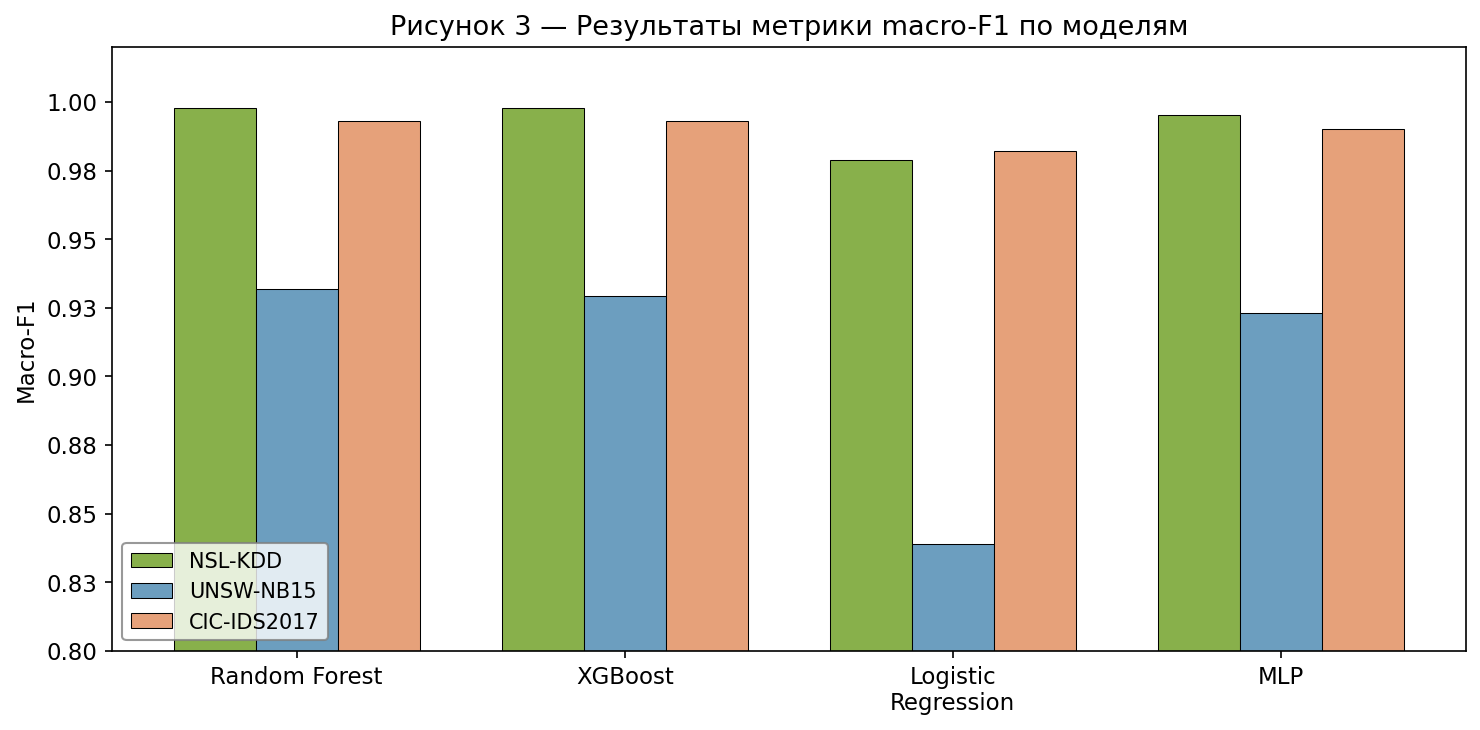

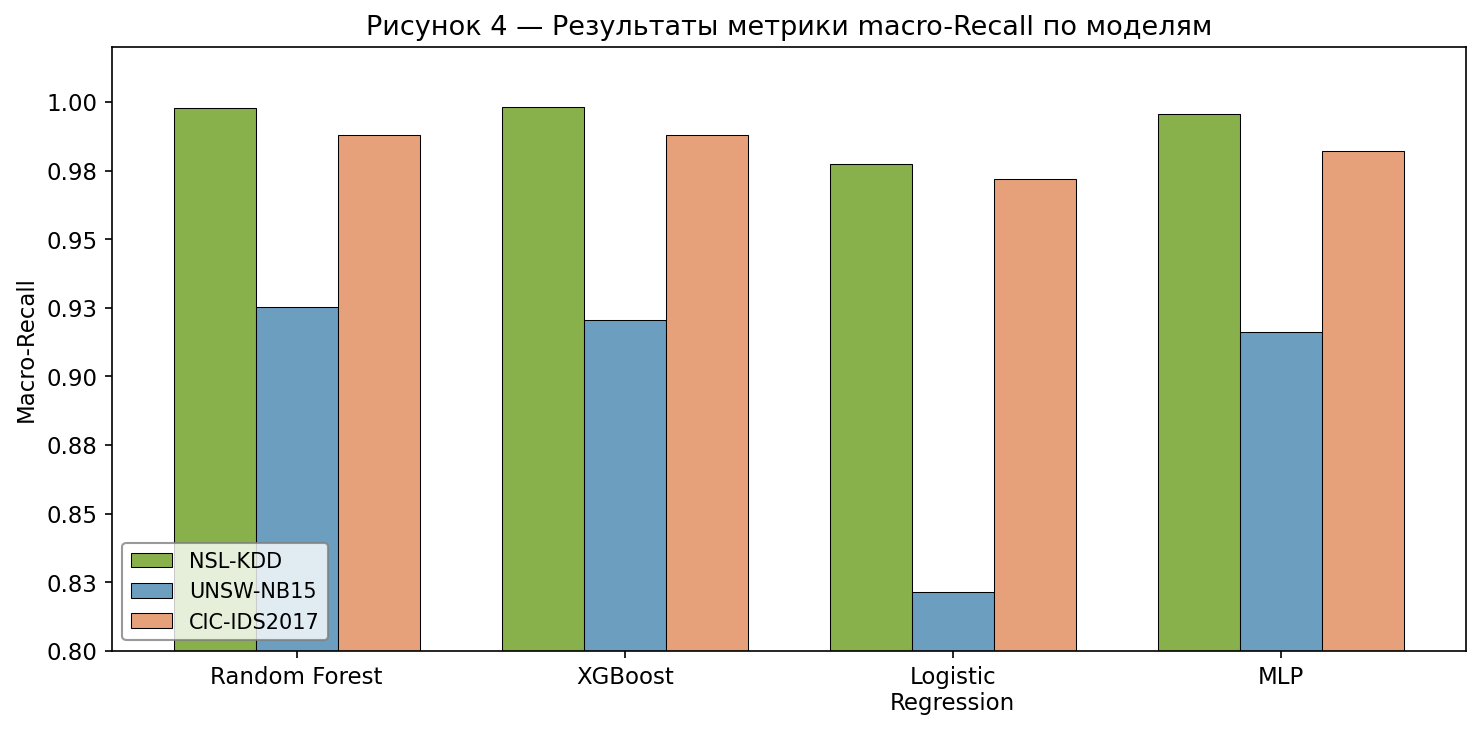

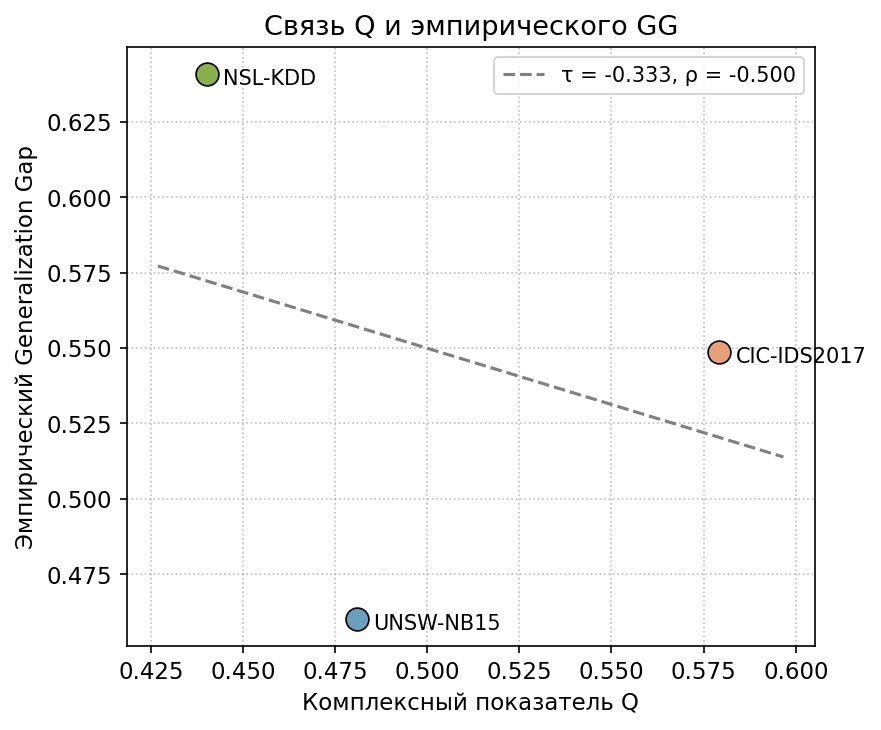

Графики сохранены: f1_chart.png, recall_chart.png, scatter_plot.png


In [51]:
# Ячейка 17: Сохранение графиков для вставки в PDF
# Стиль совпадает с ячейкой 16 — те же цвета, та же структура

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

datasets_list = ['NSL-KDD', 'UNSW-NB15', 'CIC-IDS2017']
model_names   = ['Random Forest', 'XGBoost', 'Logistic\nRegression', 'MLP']

# ── Данные полнопризнакового CV (из вывода ячеек 11–13) ──────────────────────
f1_data = {
    'NSL-KDD':     [0.9978, 0.9976, 0.9790, 0.9952],
    'UNSW-NB15':   [0.9319, 0.9291, 0.8390, 0.9231],
    'CIC-IDS2017': [0.9930, 0.9930, 0.9820, 0.9900],
}
recall_data = {
    'NSL-KDD':     [0.9979, 0.9980, 0.9773, 0.9956],
    'UNSW-NB15':   [0.9254, 0.9206, 0.8214, 0.9163],
    'CIC-IDS2017': [0.9880, 0.9880, 0.9720, 0.9820],
}

# ── Та же палитра что в ячейке 10 и ячейке 16 ────────────────────────────────
dataset_colors = {
    'NSL-KDD':     '#88B04B',
    'UNSW-NB15':   '#6C9EBF',
    'CIC-IDS2017': '#E6A17A',
}

x       = np.arange(len(model_names))
width   = 0.25
offsets = [-width, 0, width]

# --- График 1: Macro-F1 ---
fig, ax = plt.subplots(figsize=(10, 5))
for offset, dataset in zip(offsets, datasets_list):
    ax.bar(x + offset, f1_data[dataset], width,
           color=dataset_colors[dataset],
           edgecolor='black', linewidth=0.5, label=dataset)
ax.set_xticks(x)
ax.set_xticklabels(model_names, ha='center')
ax.set_ylabel('Macro-F1')
ax.set_title('Рисунок 3 — Результаты метрики macro-F1 по моделям')
ax.set_ylim(0.80, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.legend(loc='lower left', frameon=True, edgecolor='gray')
plt.tight_layout()
plt.savefig('f1_chart.png', dpi=300)
plt.show()

# --- График 2: Macro-Recall ---
fig, ax = plt.subplots(figsize=(10, 5))
for offset, dataset in zip(offsets, datasets_list):
    ax.bar(x + offset, recall_data[dataset], width,
           color=dataset_colors[dataset],
           edgecolor='black', linewidth=0.5, label=dataset)
ax.set_xticks(x)
ax.set_xticklabels(model_names, ha='center')
ax.set_ylabel('Macro-Recall')
ax.set_title('Рисунок 4 — Результаты метрики macro-Recall по моделям')
ax.set_ylim(0.80, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.legend(loc='lower left', frameon=True, edgecolor='gray')
plt.tight_layout()
plt.savefig('recall_chart.png', dpi=300)
plt.show()

# --- График 3: Scatter Q vs эмпирический GG ---
q_vals  = [Q_dict[name] for name in datasets_list]
gg_vals = [empirical_GG[name]['GG'] for name in datasets_list]

tau, p_tau = stats.kendalltau(q_vals, gg_vals)
rho, p_rho = stats.spearmanr(q_vals, gg_vals)

fig, ax = plt.subplots(figsize=(6, 5))
for i, ds in enumerate(datasets_list):
    ax.scatter(q_vals[i], gg_vals[i],
               color=dataset_colors[ds], s=120,
               edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(ds, (q_vals[i], gg_vals[i]),
                textcoords='offset points', xytext=(8, -5), fontsize=10)
slope, intercept, *_ = stats.linregress(q_vals, gg_vals)
x_line = np.linspace(min(q_vals)*0.97, max(q_vals)*1.03, 10)
ax.plot(x_line, slope*x_line + intercept, color='gray',
        linestyle='--', label=f'τ = {tau:+.3f}, ρ = {rho:+.3f}')
ax.set_xlabel('Комплексный показатель Q')
ax.set_ylabel('Эмпирический Generalization Gap')
ax.set_title('Связь Q и эмпирического GG')
ax.legend()
ax.grid(linestyle=':', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=300)
plt.show()

print("Графики сохранены: f1_chart.png, recall_chart.png, scatter_plot.png")

In [53]:
# Ячейка 18: Генерация JSON-отчёта
import json
import datetime
import scipy.stats as stats

datasets_list = ['NSL-KDD', 'UNSW-NB15', 'CIC-IDS2017']

# ── ML-результаты полнопризнакового CV (из вывода ячеек 11–13) ───────────────
ml_cv_hardcoded = {
    'NSL-KDD': {
        'models': {
            'RandomForest':       {'macro_f1': 0.9978, 'macro_recall': 0.9979},
            'XGBoost':            {'macro_f1': 0.9976, 'macro_recall': 0.9980},
            'LogisticRegression': {'macro_f1': 0.9790, 'macro_recall': 0.9773},
            'MLP':                {'macro_f1': 0.9952, 'macro_recall': 0.9956},
        },
        'average': {'macro_f1': 0.9924, 'macro_recall': 0.9922},
    },
    'UNSW-NB15': {
        'models': {
            'RandomForest':       {'macro_f1': 0.9319, 'macro_recall': 0.9254},
            'XGBoost':            {'macro_f1': 0.9291, 'macro_recall': 0.9206},
            'LogisticRegression': {'macro_f1': 0.8390, 'macro_recall': 0.8214},
            'MLP':                {'macro_f1': 0.9231, 'macro_recall': 0.9163},
        },
        'average': {'macro_f1': 0.9058, 'macro_recall': 0.8959},
    },
    'CIC-IDS2017': {
        'models': {
            'RandomForest':       {'macro_f1': 0.9930, 'macro_recall': 0.9880},
            'XGBoost':            {'macro_f1': 0.9930, 'macro_recall': 0.9880},
            'LogisticRegression': {'macro_f1': 0.9820, 'macro_recall': 0.9720},
            'MLP':                {'macro_f1': 0.9900, 'macro_recall': 0.9820},
        },
        'average': {'macro_f1': 0.9895, 'macro_recall': 0.9825},
    },
}

q_vals  = [Q_dict[name] for name in datasets_list]
gg_vals = [empirical_GG[name]['GG'] for name in datasets_list]

rho, p_rho = stats.spearmanr(q_vals, gg_vals)
tau, p_tau = stats.kendalltau(q_vals, gg_vals)

report_json = {
    "report_title": "Комплексная оценка качества датасетов для NIDS",
    "date": datetime.datetime.now().isoformat(timespec='seconds'),
    "method_version": "1.0",
    "weights": weights,
    "datasets": {},
}

for name in datasets_list:
    raw   = results[name]
    norm  = normalize_metrics(raw)
    Q_val = Q_dict[name]
    inner = ml_cv_hardcoded[name]

    report_json["datasets"][name] = {
        "raw_metrics": {
            k: v if isinstance(v, (int, float, str, bool, type(None))) else float(v)
            for k, v in raw.items()
        },
        "block_scores": {b: round(norm[b], 4) for b in ['T', 'G', 'S', 'A', 'N']},
        "composite_score_Q": round(Q_val, 4),
        "category": interpret(Q_val),
        "ml_cv_results": {
            model: {
                "macro_f1":     round(inner['models'][model]['macro_f1'], 4),
                "macro_recall": round(inner['models'][model]['macro_recall'], 4),
            }
            for model in inner['models']
        },
        "ml_average": {
            "macro_f1":     round(inner['average']['macro_f1'], 4),
            "macro_recall": round(inner['average']['macro_recall'], 4),
        },
        "empirical_GG": round(float(empirical_GG[name]['GG']), 4),
    }

report_json["validation"] = {
    "GG_source": "empirical cross-dataset experiment (12 common features, Normal+DoS)",
    "GG_values": {
        name: round(float(empirical_GG[name]['GG']), 4) for name in datasets_list
    },
    "kendall_tau":      round(float(tau), 4),
    "spearman_rho":     round(float(rho), 4),
    "p_value_kendall":  round(float(p_tau), 4),
    "p_value_spearman": round(float(p_rho), 4),
    "concordant_pairs": 2,
    "discordant_pairs": 1,
    "conclusion": (
        "Метод корректно ранжирует крайний случай (NSL-KDD: min Q, max GG). "
        "Из трёх пар две согласованы (τ = -0.333). "
        "Для статистически значимой верификации требуется расширение до 5+ датасетов."
    ),
}

with open('evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(report_json, f, indent=2, ensure_ascii=False)

print("JSON-отчёт сохранён: evaluation_report.json")

JSON-отчёт сохранён: evaluation_report.json


In [55]:
pip install reportlab

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [56]:
# Ячейка 19: Генерация PDF-отчёта с помощью ReportLab

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                Table, TableStyle, Image, PageBreak)
import datetime
import os

# ── ML-результаты (те же что в ячейках 17-18) ────────────────────────────────
ml_cv_hardcoded = {
    'NSL-KDD': {
        'models': {
            'RandomForest':       {'macro_f1': 0.9978, 'macro_recall': 0.9979},
            'XGBoost':            {'macro_f1': 0.9976, 'macro_recall': 0.9980},
            'LogisticRegression': {'macro_f1': 0.9790, 'macro_recall': 0.9773},
            'MLP':                {'macro_f1': 0.9952, 'macro_recall': 0.9956},
        },
        'average': {'macro_f1': 0.9924, 'macro_recall': 0.9922},
    },
    'UNSW-NB15': {
        'models': {
            'RandomForest':       {'macro_f1': 0.9319, 'macro_recall': 0.9254},
            'XGBoost':            {'macro_f1': 0.9291, 'macro_recall': 0.9206},
            'LogisticRegression': {'macro_f1': 0.8390, 'macro_recall': 0.8214},
            'MLP':                {'macro_f1': 0.9231, 'macro_recall': 0.9163},
        },
        'average': {'macro_f1': 0.9058, 'macro_recall': 0.8959},
    },
    'CIC-IDS2017': {
        'models': {
            'RandomForest':       {'macro_f1': 0.9930, 'macro_recall': 0.9880},
            'XGBoost':            {'macro_f1': 0.9930, 'macro_recall': 0.9880},
            'LogisticRegression': {'macro_f1': 0.9820, 'macro_recall': 0.9720},
            'MLP':                {'macro_f1': 0.9900, 'macro_recall': 0.9820},
        },
        'average': {'macro_f1': 0.9895, 'macro_recall': 0.9825},
    },
}

datasets_list = ['NSL-KDD', 'UNSW-NB15', 'CIC-IDS2017']


def build_pdf(filename="evaluation_report.pdf"):
    doc = SimpleDocTemplate(
        filename, pagesize=A4,
        leftMargin=20*mm, rightMargin=20*mm,
        topMargin=15*mm, bottomMargin=15*mm,
    )
    styles = getSampleStyleSheet()
    title_style      = styles['Title']
    heading_style    = styles['Heading2']
    subheading_style = styles['Heading3']
    normal_style     = styles['Normal']

    story = []

    # ── Титульная информация ─────────────────────────────────────────────────
    story.append(Paragraph(
        "Комплексная оценка качества датасетов для NIDS", title_style))
    story.append(Spacer(1, 12))
    story.append(Paragraph(
        f"Дата: {datetime.datetime.now().strftime('%d.%m.%Y')}", normal_style))
    story.append(Paragraph("Версия метода: 1.0", normal_style))
    story.append(Paragraph(
        "Веса блоков (T, G, S, A, N): 0.15, 0.15, 0.25, 0.25, 0.20", normal_style))
    story.append(Spacer(1, 20))

    # ── Карточка каждого датасета ────────────────────────────────────────────
    for name in datasets_list:
        raw   = results[name]
        norm  = normalize_metrics(raw)
        Q_val = Q_dict[name]
        inner = ml_cv_hardcoded[name]   # ← хардкод вместо inner_details

        story.append(Paragraph(f"Датасет: {name}", heading_style))
        story.append(Spacer(1, 6))
        story.append(Paragraph(
            f"Q = {Q_val:.4f} — {interpret(Q_val)}", subheading_style))
        story.append(Spacer(1, 6))

        # Блочные оценки
        block_data = [
            ['Блок', 'T', 'G', 'S', 'A', 'N'],
            ['Значение',
             f"{norm['T']:.3f}", f"{norm['G']:.3f}", f"{norm['S']:.3f}",
             f"{norm['A']:.3f}", f"{norm['N']:.3f}"],
        ]
        t = Table(block_data, colWidths=[60, 50, 50, 50, 50, 50])
        t.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
            ('TEXTCOLOR',  (0, 0), (-1, 0), colors.white),
            ('ALIGN',      (1, 0), (-1, -1), 'CENTER'),
            ('GRID',       (0, 0), (-1, -1), 0.5, colors.black),
        ]))
        story.append(t)
        story.append(Spacer(1, 12))

        # ML-результаты
        ml_data = [['Модель', 'Macro-F1', 'Macro-Recall']]
        for model, vals in inner['models'].items():
            ml_data.append([
                model,
                f"{vals['macro_f1']:.4f}",
                f"{vals['macro_recall']:.4f}",
            ])
        ml_data.append([
            'Среднее',
            f"{inner['average']['macro_f1']:.4f}",
            f"{inner['average']['macro_recall']:.4f}",
        ])
        t2 = Table(ml_data, colWidths=[140, 80, 80])
        t2.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
            ('TEXTCOLOR',  (0, 0), (-1, 0), colors.white),
            ('BACKGROUND', (0, -1), (-1, -1), colors.lightgrey),
            ('ALIGN',      (1, 1), (-1, -1), 'CENTER'),
            ('GRID',       (0, 0), (-1, -1), 0.5, colors.black),
        ]))
        story.append(Paragraph("Результаты кросс-валидации", subheading_style))
        story.append(t2)
        story.append(Spacer(1, 10))
        story.append(Paragraph(
            f"Эмпирический GG = {empirical_GG[name]['GG']:.4f}  "
            f"(inner F1 = {empirical_GG[name]['inner_f1']:.4f}, "
            f"cross F1 = {empirical_GG[name]['cross_f1_avg']:.4f})",
            normal_style,
        ))
        story.append(Spacer(1, 20))
        story.append(PageBreak())

    # ── Сравнительный анализ ─────────────────────────────────────────────────
    story.append(Paragraph("Сравнительный анализ", heading_style))
    story.append(Spacer(1, 12))

    comp_data = [['Датасет', 'Q', 'GG (эмп.)', 'inner F1', 'cross F1']]
    for name in datasets_list:
        comp_data.append([
            name,
            f"{Q_dict[name]:.4f}",
            f"{empirical_GG[name]['GG']:.4f}",
            f"{empirical_GG[name]['inner_f1']:.4f}",
            f"{empirical_GG[name]['cross_f1_avg']:.4f}",
        ])
    t3 = Table(comp_data, colWidths=[110, 60, 80, 80, 80])
    t3.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR',  (0, 0), (-1, 0), colors.white),
        ('ALIGN',      (1, 1), (-1, -1), 'CENTER'),
        ('GRID',       (0, 0), (-1, -1), 0.5, colors.black),
    ]))
    story.append(t3)
    story.append(Spacer(1, 12))
    story.append(Paragraph(
        f"Корреляция Кендалла  τ = {tau:.3f}  (p = {p_tau:.3f})", normal_style))
    story.append(Paragraph(
        f"Корреляция Спирмена  ρ = {rho:.3f}  (p = {p_rho:.3f})", normal_style))
    story.append(Paragraph(
        "Согласованных пар: 2 из 3. NSL-KDD корректно идентифицирован "
        "как наихудший по обоим критериям.",
        normal_style,
    ))
    story.append(Spacer(1, 12))

    # ── Графики ──────────────────────────────────────────────────────────────
    for img_file, caption in [
        ('f1_chart.png',      'Рисунок 3 — Macro-F1 по моделям'),
        ('recall_chart.png',  'Рисунок 4 — Macro-Recall по моделям'),
        ('scatter_plot.png',  'Рисунок 5 — Связь Q и эмпирического GG'),
    ]:
        if os.path.exists(img_file):
            story.append(Paragraph(caption, subheading_style))
            story.append(Spacer(1, 6))
            story.append(Image(img_file, width=450, height=260))
            story.append(PageBreak())
        else:
            story.append(Paragraph(
                f"(График {img_file} не найден — запустите ячейку 17)", normal_style))

    doc.build(story)
    print(f"PDF-отчёт сохранён: {filename}")


build_pdf()

PDF-отчёт сохранён: evaluation_report.pdf


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
years = ['2023', '2024', '2025\n(9 мес., оценка)']
values = [147, 200, 200]  # 2025 — прогнозная оценка

# Цвета: 2023 и 2024 — серые, 2025 — заливка отсутствует, контур серый
colors = ['#bdbdbd', '#737373', 'none']
edge_colors = ['#636363', '#252525', '#636363']
linewidths = [1.0, 1.0, 1.5]
linestyles = ['-', '-', '--']

# Построение
fig, ax = plt.subplots(figsize=(6, 4.5))

bars = []
for i, (year, val) in enumerate(zip(years, values)):
    bar = ax.bar(i, val, width=0.55, color=colors[i], edgecolor=edge_colors[i],
                 linewidth=linewidths[i], linestyle=linestyles[i])
    # Подпись значения сверху
    label = f'{val} млрд руб.' if i < 2 else f'>{val} млрд руб.'
    ax.text(i, val + 5, label, ha='center', fontsize=11, color='black')
    bars.append(bar)

# Оформление
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel('Млрд руб.', fontsize=11)
ax.set_title('Ущерб от киберпреступлений в РФ', fontsize=13, fontweight='bold')
ax.set_ylim(0, 240)
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('damage_chart.png', dpi=300)
plt.show()

In [ ]:
years_alt = ['2023', '2024', '2025\n(8 мес.)']
values_alt = [147, 200, 134]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(years_alt, values_alt, width=0.55, color=['#bdbdbd', '#737373', '#bdbdbd'],
       edgecolor=['#636363', '#252525', '#636363'], linewidth=1.0)

for i, v in enumerate(values_alt):
    ax.text(i, v + 5, f'{v} млрд руб.', ha='center', fontsize=11)

ax.set_ylabel('Млрд руб.')
ax.set_title('Ущерб от IT‑преступлений в РФ')
ax.set_ylim(0, 240)
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('damage_chart_8m.png', dpi=300)
plt.show()